<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Dieses Dokument ist von mir (FEZ) selbstständig geschreiben und verfasst worden. Viele Funktionen sind von anderen übernommen und abgewandelt worden. Da der Code in VS Code geschrieben wird, wird teilweise auf den MS Copilot (K.I. Modell) zurückgegriffen. Dieser wird unterstützend und nicht generierend benutzt. Ich entschuldige mit hiermit auch formal für das unglaublich schlimme Denglisch in den Kommentaren und der Dokumentation. 

Vorlage zum bestimmen aller im Praktikum benötigten Formel und intigriertem Latex Export für eine effizientere Nutzung.

Diese Version ist noch nicht aktiell. Daher führen viele Überschriften in Leere Kapitel. (Stand 07.03.2026)

 
----

# Inhaltsverzeichnis für den Papulator
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Funktionen der Fehlerrechnung](#Funktionen-der-Fehlerrechnung)
    * [Runden signifikanter Stellen](#Runden-signifikanter-Stellen)
    * [Gaussische Fehlerfortpflanzung](#Gaussische-Fehlerfortpflanzung)
    * [Berechnung von Messwert und Fehler](#Berechnung-von-Messwert-und-Fehler)
    * [Signifikante Standartabweichung zweier Messwerte](#Signifikante-Standartabweichung-zweier-Messwerte)

* [Messdatenimporte](#Messdatenimporte)
    * [Patterns](#Patterns)
    * [Import von Experimentdaten](#Import-von-Experimentdaten)

* [Latex Export](#Latex-Export)
    * [Export von Gleichungen](#Export-von-Gleichungen)
    * [Export von Einzelergebnissen](#Export-von-Einzelergebnissen)
    * [Export von Messreihen (Tabelle)](#Export-von-Messreihen-(Tabelle))

+ [Calc_Everything](#Calc_Everything)

* [Plotting](#Plotting)

* [Ergebnisse der Aufgaben](#Ergebnisse-der-Aufgaben)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [545]:
versuchsnummer = "233"
versuchsname = "Foruieroptik"
aufgabe = "0z"

# Wichtige Konstanten
# Heidelberger Ortsgravitationsbeschleunigung in m/s^2
g_hd = 9.80984
err_g_hd = 0.00002

# Farben in hex
gruen="#1b722f"
hellgruen = "#1ba97f"
rot = "#b92d3a"
weinrot="#721c24"
blau="#073984"
lila = "#6610f2"

# Import aller genutzen Libaries

In [546]:
# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

from decimal import Decimal, ROUND_HALF_UP, getcontext # Besonders für sig. Runden
import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy import signal
from scipy.signal import find_peaks, find_peaks_cwt
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd # Auch wichtig für den Latex Export 
import csv
import re
from typing import List


# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

# Display und Output
from IPython.display import display, Math, Latex, HTML

---
---
# Funktionen der Fehlerrechnung
Folglich werden eigene Funktionen definiert, die das Auswerten von Versuchen enorm vereinfachen sollen. Diese sind in vielen Punkten an fremden Code orientiert. 

## Runden signifikanter Stellen

In [547]:
def round_sig_digs(val, errVal):
    """
    Funktion zur Rundung eines Fehlers und die Anpassung des Messwertes daran. Diese Funktion wurde etwas umständlicher 
    geschrieben, da python mit Floats und Runden schnell in Probleme rennt. Daher musste hier mit dezimal gearbeitet werden.
    Zudem sollten besonders kleine und große Messwerte in der Dezimalschreibweise geschrieben werden, damit diese auch 
    für Protokolle geiegnet sind.

    Parameter
      
    **val** : float
        Messwert

    **errVal** : float
        Ungenauigkeit des Messwertes

    Return
     -
    **value_rounded** : str
        Gerundeter Messwert

    **error_rounded** : str
        Gerundete Ungenauigkeit des Messwertes

    **res** : str
        "Messwert \\pm Fehler"
    """

    # Daten zu Dezimal wechseln, da Floats probleme machen
    val = Decimal(str(val))
    errVal = Decimal(str(errVal))

    exp = int(math.floor(math.log10(float(errVal))))

    if round(float(errVal / (Decimal(10) ** exp))) < 3:
        exp -= 1

    scale = Decimal(10) ** exp

    val_round = (val / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale
    err_round = (errVal / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale

    # Exponent des Messwerts bestimmen
    if val_round != 0:
        val_exp = int(math.floor(math.log10(abs(float(val_round)))))
    else:
        val_exp = 0

    # wissenschaftliche Schreibweise, Werte auf selben Exponenten
    if val_exp <= -1:
        scale = Decimal(10) ** val_exp
        v = (val_round / scale)
        e = (err_round / scale)
        digits = -exp + val_exp
        res = f"({v:.{digits}f} \\pm {e:.{digits}f}) e{val_exp}"
    else:
        if exp > 0:
            res = f"{val_round} \\pm {err_round}"
        else:
            digits = -exp
            res = f"{(val_round):.{digits}g} \\pm {(err_round):.{digits}g}"
    return val_round, err_round, res

## Gaussische Fehlerfortpflanzung

In [548]:
def gff(func, errPronePar):
    """
    Kann die Fehlerformel einer gegebenen Gleichung bestimmen.

    Parameters
      
    **func** : sympy function
        Funktion dessen Fehler bestimmt werden soll.

    **errPronePar** : Array
        Liste (Array) aller fehlerbehafteten Größen der Gleichung con sp.Symbols
        Diese Werte werden als x_sym, y_sym, z_sym etc. bezeichnet und sind ungleich den Werten für x, y, z.
        Für die Werte wird daher die Bezeichnung x_val, y_val, z_val etc. genutzt und für deren Fehler err_x, err_y, err_z etc.

    Return
      
    **absolut_err** : sympy function
        Gibt die Fehlergleichung des absoluten Fehlers wieder. 

    **relativ_err** : sympy function
        Gibt die Fehlergleichung des relativen Fehlers wieder. 
        
    **errProneParamters** : array
        Liste aller Fehlerbehafteten Größen
    """ 

    error = 0
    errProneParamters = []
    for errPar in errPronePar:
        d = sp.symbols('thisWillTurnDelta' + errPar.name)
        partial = sp.diff(func, errPar) * d  # Die Funktion wird nach der fehlerbehafteten Variable abgeleitet
        error = error + partial**2 # Fehler werden quadratisch aufsummiert
        errProneParamters.append((errPar,d))
    absolut_err=sp.simplify(sp.sqrt(error),rational = True)             
    relativ_err=sp.simplify(sp.sqrt(error/func**2),rational = True)

    # Debugging Print
    # print(f"Die Fehlerfunktion zur Ausgangsfunktion {func} wurde erfolgreich nach den Fehlergrößen {errPronePar} bestimmt.")

    return absolut_err, relativ_err, errProneParamters

## Berechnung von Messwert und Fehler

In [549]:
def calc_with_err(func, errFunc, values):
    """
    Methode zum berechnen von Werten und deren Fehler.

    Parameter
      
    **func** : sympy function
         Funktionen mit Parametern. 

    **errFunc** : sympy function
        Die zu func gehörende Fehlerformel. Wird über gff bestimmt.

    **values** : 
        Werte, die in die Funktionen eingesetzt werden.
        Als array von Tupeln der Form [(a,da),(b,db),...] oder als array/liste [a,da,b,db,...] 
        (Reihenfolge muss die sein, in der die Argumente in der Funktion genommen werden)

    Return
      

    """

    #Falls der Input in mehrere Tupel aufgeteilt ist, werden diese zu einem Array zusammengefügt 
    if (np.ndim(values) != 1):                    
        values = np.concatenate(values)
    result = func(*values[::2])
    uncertainty = errFunc(*values)

    # Debigging Print
    # print(f"Die Ergebnisse wurden erfolgreich durch Funktion und Fehlerfunktion bestimmt!")

    return result, uncertainty

## Signifikante Standartabweichung zweier Messwerte

In [550]:
def sigma_abweichung(p1, p2, err_p1 = 0.0, err_p2 = 0.0):
    """
    Funktion zum berechnen der Sigma-Abweichugn von zwei Messwerten, oder einem Messwert und einem Literaturwert.
    """
    return abs(p1 - p2)/(np.sqrt(err_p1**2 + err_p2**2))

    if err_p1 == 0 and err_p2== 0:
        print("Für die Sigma-Abweichung muss mindestens ein Wert fehlerbehaftet sein!")
    else:
        abweichung = abs(p1 - p2)/(np.sqrt(err_p1**2 + err_p2**2))
        # return abweichung
        return abs(p1 - p2)/(np.sqrt(err_p1**2 + err_p2**2))

---
---

# Messdatenimporte

Für die Auswertung von Versuchen ist es nicht selten, dass Messwerte in _CSV_ oder in _TXT_ Dateien gespeichert sind. Daher sollen diese Vernünftig eingelesen und verarbeitet werden, um das Benutzen der Daten möglichst einfach und instuinktiv zu gestalten. 

Um das Handeln von CSV Tabellen möglichst einfach zu gestalten, werden RIGEX-Pattern genutzt. Das heißt, wenn die Tabelle vor einem Versuch ordentlich strukturiert ist, können die Werte sofort genutzt werden, so wie es gewünscht ist. Dabei sollen folgende Eigenschaften erfüllt sein:
* Das Nutzen einer Kopfzeile ist nicht nur möglich, sondern explizit empfohlen. 
* Erkennung eines Messwertes, seiner Einheit und einer Potenz. Das hat dan bspw. die Form: _(name [unit] 10^{power})_
* Der zum Messwert gehörende Fehler. Dies ist meist ein Ablese Fehler. Die Bennenung sollte dabei: _err name_ sein. 
* Direkte Auswerten von Messreihen. Soll bspw. über mehrere Werte gemittelt werden, so wird automatisiert Mittelwert, Standartabweichung und gesamt Fehler der Messreihe bestimmt. 
* Dimensionslose Größen sollen erkannt werden. 
* Einstellung eines Indexes. Dies kann entweder die nummerische Angabe des Messdurchganges sein, oder der Parameter-Name. Wird bspw. dieselbe Messung in Wasser und in Luft durchgeführt, so sollen dies die Parameter-Namen sein. Diese sollen in der ersten Spalte der Tabelle stehen. 

## Patterns

In [551]:
# RegEx Patterns, um autoamtisiert Schemata anzuwenden und Daten anhand dieser auszuwerten. 

# Finden eines Messwertes, seiner Einheit und seiner Potenz
pattern = re.compile(
        r'^\s*'
        r'(?P<name>[^\[]+?)'    # alles bis zur ersten '['      # Name
        r'\s*\[\s*'             # echtes '['
        r'(?P<unit>[^\]]+?)'    # alles bis zur ']'             # Einheit
        r'\s*\]'                # echtes ']'
        r'(?:\s*10\^(?P<power>-?\d+))?'                         # optionale 10^n   
        r'\s*$'
    )

series_pattern = series_pattern = re.compile(
        r'^(?P<base>\w+)_\d+'
        r'(?:\s*\[\s*(?P<unit>[^\]]+)\s*\])?'
    )

# Index Spalte idx
index_pattern = re.compile(
    r'idx\s*'
    )

# Spalte die Ignoriert werden sill ign
ignore_pattern = re.compile(
    r'(?:ign[^,]*\s*,\s*)?'
)

# Messwert mit Einheit
messurment_pattern = re.compile(
    r'(?P<value>Messwert)\s*$$(?P<unit>[^$$]+)\]\s*,\s*'
)

# Fehler des Messwertes
error_pattern = re.compile(
    r'(?:err\s+Messwert\s*,\s*)?'
)

## Import von Experimentdaten

Das einlesen von Messweerten und das speichern dieser als Arrays für einen besseren zugriff. Automatisches herausfinden von Messwert und dazugehörigem Fehler.

In [552]:
def import_experimental_data(path:str = versuchsnummer + ".csv", setDelimiter:str = ",", setHeader:int = 0, setIndex_col:int = None):
    """
    
    Parameter
     ----
    **path**: str
        Relatives verzeichnes der einzulesenden Datei. Am besten CSV-Datei einfach unter *versuchsnummer.csv* im Python-Folder speichern.

    **setDelimiter**: str
        Default ist hier das Komma:  > , <

    **setHeader**: int
        Setzt fest, was die Header-Row ist. Default ist 0 (die oberste Row) 

    Return
     ----
    **cleanded** : Pandas DataFrame
        DataFrame, welches sicher zum weiterverwenden ist. NaN und ähnliches werden herausgefiltert und per Print
    """

    # Liest die Daten unmaipuliert
    try:
        df = pd.read_csv(path, delimiter=setDelimiter, header=0, index_col=None)
    except FileNotFoundError:
        print(f"The file {path} was not found.")
     
    # Wir erwarten nicht, dass zwei perfekt identische Zeilen existieren koennten, daher werden alle identischen Zeilen geloescht. Somit werden auch alle NaN Zeilen entfernt    
    # Langfristig soll das noch verschönert werden und wirklich nur NaN Zeilen gelöscht werden
    no_NaN_data = df.drop_duplicates(keep= False)
    df.reset_index(drop=True, inplace=True)

    return no_NaN_data 

# Speichert direkt das DataFrame als Variable, so kann dieses direkt in anderen Cells benutzt werden.
# experimental_data = import_experimental_data()


---
---

# Latex Export

### Erstellen der dedizierten Dartei zum Speichern der Werte für **LATEXT**

Folgender Code sollte einmal ausgeführt werden, damit direkt die Datei zum Speichern erstellt werden kann. Unbedingt daran denken, die Versuchsnummer anzupassen, die Werte anderer Versuche könnten ansonsten verloren gehen. Es gibt jedoch eine sicherheits Kopie. 

Die File wird Folgendes beinhalten:
* Formel, sowie Formel nach gff
* Berechnete Werte und deren Fehler
    * Wert + Fehler
    * Tabellen Export

In [553]:
def create_tex_result_file(fileName:str = f"python-results.sty", relativePath:str="../Auswertung/"):
    """
    Diese Method erstellt automatisch eine tex-Datei, in dem Messwerte bzw. deren Ergebnisse, Tabellen weiteres als variable gespeichert werden, die hier in diesem Python-code bestimmt werden.
    Die File wird unter *Versuche/${versuchsnummer}$/Auswertung/python-results.tex* zufinden sein. Am einfachsten ist es jedoch die Parameter frei zuhalten, da ansonsten auch das Verzeichnis in der *main.tex* 
    angepasst werden muss. 

    Die Python-File muss im Python-Ordner des jeweiligen Versuches liegen!

    Parameter
      
    **fileName** : 
        neuer Name, falls die Datei besonders heißen soll.

    Return
     ---
    **path** : str
        Gibt den Path zur file wieder, welche autoamtisch generiert. In diese sollen später die Formeln geschrieben werden.
    """

    path = relativePath + fileName

    if os.path.isfile(path):
        print(f"{fileName} existiert bereits.")
        pass
    else:
        print(f"{fileName} wird in {relativePath} erzeugt.")
        with open(path, 'w') as file:
            file.write("% Dies ist eine automatisch generierte Datei. Hier werden automatisiert Variablen fuer Formeln, Ergebnisse und Tabellen erstellt. \n% Bitte nicht in diese Datei schreiben. Informationen koennten geloescht oder nicht richtig verarbeitet werden. \n\n%  _          _   _       _______      \n% | |        | | ( )     |__   __|\n% | |     ___| |_|/ ___     | | _____  __\n% | |    / _ \\__| / __|    | |/ _ \\/ /\n% | |___|  __/ |_  \\__ \\   | |  __/>  < \n% |______\\___|\\__| |___/    |_|\\___/_/\\_\\\n\n\n") 

        with open(path + "-BackUp.sty", 'w') as bFile:
            bFile.write("% Dies ist eine automatisch generierte Datei. Hier wird dediziert ein Back-Up erstellt, damit Werte nicht verloren gehen. \n\n%  _          _   _       _______      \n% | |        | | ( )     |__   __|\n% | |     ___| |_|/ ___     | | _____  __\n% | |    / _ \\__| / __|    | |/ _ \\/ /\n% | |___|  __/ |_  \\__ \\   | |  __/>  < \n% |______\\___|\\__| |___/    |_|\\___/_/\\_\\\n\n\n") 

    return path

# pyPath ist die File, in die der Latex Export geschehen soll.
pyPath = create_tex_result_file()

python-results.sty existiert bereits.


## Export von Gleichungen

In [554]:
def function_to_latex(func):
    # , texVarName:str, texCom:str
    """
    Zeigt die Formel als gerenderte Math-Darstellung und darunter
    den Latex-Quelltext, der per Button kopiert werden kann. (Für leichtere Benutzung als HTML).
    
    Zudem wird die Latexformel als Variable in Latex gespeichert.

    Parameters
      
    **f** : sympy function

    **texVarName** : str
        Einzigartiger Name der Variablen. Dieser wird zum überschreiben alter Formel gebraucht.

    **texCom** : str
        setzt den newcommand-Kürzel für latex fest. Setzte kein Backslash! Auch texCom muss einzigartig gesetzt werden.
    """
    # print("Die gegebene Funktion lautet: \n")
    display(Math(sp.latex(func, long_frac_ratio=2).replace('thisWillTurnDelta', r'\Delta ')))

    print("Hier ist der dazugehörige Latex code: \n")
    latex_str = sp.latex(func, long_frac_ratio=2).replace('thisWillTurnDelta', r'\Delta ')
    html = f"""
    <div style="margin-top:0.5em;">
        <code id="latex-code-{id(func)}">
            {latex_str}
        </code>
        <button onclick="
            const tex_as_txt = document.getElementById('latex-code-{id(func)}').innerText;
            navigator.clipboard.writeText(tex_as_txt)
        " style="
            margin-left:8px;
            padding:2px 6px;
            cursor:pointer;
        ">
            Kopieren
        </button>
    </div>
    """
    display(HTML(html))


    # # Hinzufuegen bzw. Ueberschreieben der Formel in die Sammlung
    # with open(pyPath, 'r') as file:
    #     lines = file.readlines()
    # found = False

    # with open(pyPath, 'r') as file:
    #     for lineNum,  line in enumerate(lines, 1):
    #         if texVarName in line: # Checkt, ob der Variablen Name bereits vergeben ist.
    #             lines[lineNum] = "\\newcommand{\\" + texCom + "}{" + latex_str + "} \n\n"
    #             found = True
    #             # Deugging print
    #             # print(f'{texVarName} is at line {lineNum}') 

    # if not found:
    #     print("Die neue Funktion wurde hinzugefügt")
    #     with open(pyPath, 'w') as file:
    #         file.writelines(lines) # Schreibt den alten Stand
    #         file.write("\n\n% " + texVarName + "\n") # Fügt die Variable als Kommentar hinzu
    #         file.write("\\newcommand{\\" + texCom + "}{" + latex_str + "} \n\n")
    # else:
    #     print("Die alte Funktion wurde erfolgreich überschrieben.")
    #     with open(pyPath, 'w') as file:
    #         file.writelines(lines)

## Export von Einzelergebnissen

## Export von Messreihen (Tabelle)

In [555]:
def table_to_latex(df_tex: str, texVarName: str, texCom: str):
    """
    Fügt aus einem DataFrame entstandene Latex Tabelle der special Python File hinzu.

    Parameters
      
    **df_tex** : pd.DataFrame.to_latex
        Uebersetztes DataFrame. Kann Label und Caption handlen. Dezimaltrennung steht auf ','.

    **texVarName** : str
        Einzigartiger Name der Variablen. Dieser wird zum überschreiben alter Formel gebraucht.

    **texCom** : str
        setzt den newcommand-Kürzel für latex fest. Setzte kein Backslash! Auch texCom muss einzigartig gesetzt werden.

    Returns
     --
    Schreibt automatisch in die sty file
    """
    
    # Hinzufuegen bzw. Ueberschreieben der Tabelle in die Sammlung
    with open(pyPath, 'r') as file:
        lines: List[str] = file.readlines()
    found = False

    with open(pyPath, 'r') as file:
        for lineNum,  line in enumerate(lines):
            if texVarName in line: # Checkt, ob der Variablen Name bereits vergeben ist.
                print(f'{texVarName} starts at line {lineNum + 1}') 
                found = True
                table_start_line = lineNum
                break

    if not found:
        print(f"Die neue Tabelle ({texVarName}) wurde hinzugefügt")
        with open(pyPath, 'w') as file:
            file.writelines(lines) # Schreibt den alten Stand
            file.write("\n% " + texVarName + "\n")
            file.write("\\newcommand{\\" + texCom + "}{" + df_tex + "}\n\n")
    else:
        print(f"Die alte Tabelle ({texVarName}) wird überschrieben.")
        start_table = table_start_line + 1
        while start_table < len(lines) and lines[start_table].strip() == "":
            # Leere Zeile überspringen – das ist unser Marker
            start_table += 1
            break   # Wir wollen nur die erste leere Zeile

        # Falls kein leerer Marker gefunden wurde, gehen wir davon aus,
        # dass die Tabelle direkt in der nächsten Zeile startet.
        if start_table >= len(lines):
            start_table = table_start_line + 1

        end_table = start_table

        while end_table < len(lines):
            cur = lines[end_table].strip()

            # Abbruchbedingungen:
            if (
                cur.startswith(r"\\newcommand")
                or cur.startswith(r"\\section")
                or cur.startswith(r"\\subsection")
                or cur.startswith(r"\\begin")
            ):
                break

            end_table += 1

        if end_table > start_table:
            del lines[start_table - 1:end_table]

        insertion_point = table_start_line + 1  # Direkt nach der Zeile mit texVarName
        new_block = [
            # "\n\n",
            f"% {texVarName}\n",
            f"\\newcommand{{\\{texCom}}}{{{df_tex}}}\n",
        ]
        lines[insertion_point:insertion_point] = new_block

        with open(pyPath, 'w') as file:
            file.writelines(lines)

### Finaler Export 

Für die Auswertung sollen Messwerte und Fehler in einer Zelle stehen. Dies tut *tab_merge_val_err* automatisiert.

In [556]:
def tab_merge_val_err(df: pd.DataFrame, show_series_values:bool=False, setTexTabCap: str="", setTexTabLab:str=""):
    """Sucht im DataFrame nach einem Asdruck:
        "<name> [<unit>] <power>"
    und dem dazugehörigem Fehlerausdruck:
        "err <name>".
    Erstellt ein neues DataFrame für den Latex-Export

    Parameters
      
    **df* : pd.DataFrame
        Original data frame.

    **show_series_values** : bool
        Rather the table should show the experimental data or just its mean
        

    Returns
     --
    pd.DataFrame
        Eine Kopie von ``df``.
    """

    # Kopiert das alte DataFrame
    df_tex = pd.DataFrame(index=df.index)


    def format_tex(row):
        val = row[col]
        err = row[err_col]
        # return f'({val} \\pm {err}) \\mathrm{{{header_unit}}}'
        val_r, err_r = round_sig_digs(err, val)
        return f'${val_r} \\pm {err_r}$'
    
    #      ---
    # 1) Einzelmessungen
    #      ---

    for col in df.columns:
        col_match = pattern.match(col)

        if not col_match:
            # No header that follows the expected schema – skip it
            # print(f'Skipping column {col!r}: not "<value> [<unit>] <power>"')
            continue

        # Extract the captured parts
        name = col_match.group('name').strip()
        unit = col_match.group('unit').strip()
        power = col_match.group("power")   
        # print(f'Found measurement column: name={name!r}, unit={unit!r}, power={power!r}')

        # Build the name of the error column that must exist
        err_col = f'err {name}'
        if err_col not in df.columns:
            # print(f'No error column "{err_col}" for measurement "{name}" - skipping')
            continue

        if power:
            header_unit = f"$\\mathrm{{{unit}}} \\cdot 10^{{{power}}}$"
        else:
            header_unit = f"$\\mathrm{{{unit}}}$"

        df_tex[f'{name} [{header_unit}]'] = df.apply(format_tex, axis=1)


    #      ---
    # 2) Messreihen
    #      ---
    grouped = {}

    for col in df.columns:
        series_match = series_pattern.match(col)
        if series_match:
            base = series_match.group("base")
            unit = series_match.group("unit")
            # power = col_match.group("power")
            grouped.setdefault(base, {"cols": [], "unit": unit})
            grouped[base]["cols"].append(col)


    # --- Berechnungen ---
    for base, info in grouped.items():
        cols = info["cols"]
        series_unit = info["unit"] or ""


        err_col = f"err {base}"
        if err_col not in df.columns:
            continue

        values = df[cols]

        if show_series_values == True:
            # Einzelwerte in DataFrame hinzufuegen
            for ind, col in enumerate(cols, start=1):
                df_tex[f'{base}_{ind} [{unit}]'] = df.apply(format_tex, axis=1)

        # Mittelwert
        mean = values.mean(axis=1)

        # Standardabweichung
        std = values.std(axis=1, ddof=1)

        # Fehler des Mittelwerts
        stat_err = std / np.sqrt(len(cols))

        # systematischer Fehler
        sys_err = df[err_col]

        # Gesamtfehler
        total_err = np.sqrt(stat_err**2 + sys_err**2)

        # if power:
        #     header_unit = f"\\mathrm{{{unit}}} \\cdot 10^{{{power}}}"
        # else:
        #     header_unit = f"\\mathrm{{{unit}}}"

        formatted = []

        for m, e in zip(mean, total_err):
            m_r, e_r = round_sig_digs(e, m)
            formatted.append(f"${m_r} \\pm {e_r}$")

        df_tex[f"$\\overline{{{base}}} [\\mathrm{{{series_unit}}}]$"] = formatted

    setTexTabCap="Dies ist die Caption der Tabelle"
    setTexTabLab="bspTab"

    table_to_latex(df_tex.to_latex(decimal=',', caption=setTexTabCap, label=setTexTabLab, position="h", index=False), texVarName="Beispielhafet Tabelle", texCom="bspTab")

    print(df_tex.to_latex(decimal=',', caption=setTexTabCap, label=setTexTabLab, position="h"))
    return df_tex.to_latex(decimal=',', caption=setTexTabCap, label=setTexTabLab, position="h")


# combine_value_error(clean_data)

### Berechnen neuer Spalten mit Fehler

Die folgende Funktion berechnet anhand einer gegebenen Formel und den gegebenen Parametern die Ergebnisse einer neuen Spalte mit Ihren Fehlern.

In [557]:
def add_column_by_formula(func, errProneParams, headerName:str, headerUnit:str, err_free_params = []):
    pass

---
---

# Calc_Everything

In [558]:
# Code by Luca Hanfer (leicht verändert)
def calc_everything(function, params, data, params_without_error=[], print_formula:bool=True):
    """
    Returned Berechneten Wert plus Fehler. Zudem werden die Formeln als Latex-Code ausgeworfen.

    Parameter
      
    **function**: sympy Funktion mit Parametern. In diese werden die Messwerte eingesetzt.

    **params**: Parameter der Funktion. Diese werden als Array von Sympy-Symbolen gebraucht. Bspw. [x, y, z]

    **data**: 2D-Array mit den Messdaten, sodass die Zeilen die Form haben: [Parameter 1, Fehler Parameter 1, Parameter 2,...]
        Die Funktion wird zeilenweise angewandt. Wird kein Fehler für einen Parameter angenommen, kann diese Spalte entweder mit dem Wert 0 
        an die Funktion gegeben werden oder ganz weggelassen werden. Dann muss allerdings der betreffende Parameter bei params_without_error angegeben werden.

    **params_without_error**: Alle Parameter zu denen kein Fehler explizit in den Daten angegeben ist. Dieser wird auf 0 gesetzt und kommt dann
        auch nicht in der Latex Form der Fehlerformel vor

    """

    exp_data = np.zeros((data.shape[0],data.shape[1]+len(params_without_error)))
    i = 0      # läuft durch die Parameter
    j = 0      # läuft durch die expanded data
    z = 0      # läuft durch die eingegebene data, also die Messwerte und deren Fehler
    # Läuft durch jeden Parameter und seinen Fehler
    while (i < len(params)):
        # Checkt, ob der Parameter Fehlerbehaftet ist. Wenn, dann wird an j-ter Stelle des exp_data der z-te Parameter aus data einegfügt.
        if (params[i] in params_without_error):
            exp_data[:,j] = data[:,z]
            i = i + 1
            j = j + 2
            z = z + 1
        else:
            exp_data[:,j] = data[:,z]
            exp_data[:,j+1] = data[:,z+1]
            i = i + 1
            j = j + 2
            z = z + 2

    # Create variable that stores parameters that have no assigned uncertainty    
    params_with_error = []
    j = 0
    for n in np.arange(0,len(params)):
        if not (params[n] in params_without_error):
            params_with_error.append(params[n])
            j = j + 1
    
    # Get the given function and error function as numpy functions
    f = sp.lambdify(params, function, "numpy")
    absolut_err, relativ_err, parameters = gff(function,params) # Gauss Fehlerfortpflanzung
    err_abs = sp.lambdify(np.concatenate(parameters), absolut_err, "numpy")

    # Calculate the results for each row of data
    results = np.zeros((data.shape[0],2))
    for n in np.arange(0, data.shape[0]):
        results[n,:] = calc_with_err(f, err_abs, exp_data[n,:])
    
    if (len(results) < 10):
        print("Results:")
        print(results)

    # Substitutes 0 for the uncertainty of the parameters without error, so it doesnt show up in the Latex Code
    for p in params_without_error:
        absolut_err = absolut_err.subs('thisWillTurnDelta'+p.name,0)
    for p in params_without_error:
        relativ_err = relativ_err.subs('thisWillTurnDelta'+p.name,0)

    if print_formula:
        # Wiedergabe des Latex-Codes
        function = sp.simplify(function,symbols = params, rational= True)
        function = sp.separatevars(function)
        # print("gegebene Funktion:")
        function_to_latex(function)

        print("Formel des absoluten Fehlers der gegebenen Funktion:")
        function_to_latex(absolut_err)

        print("Formel des relativen Fehlers der gegebenen Funktion:")
        function_to_latex(relativ_err)

    return(results)


def calc2(function, params,data, params_without_error = [], p_latex:bool = True):
    length = 1
    for e in data:
        if(np.shape(np.array(e)) != ()):
            length = np.shape(np.array(e))[0]
            break
    data_2d = np.zeros((length,len(data)))
    for i in range (0,len(data)):
        data_2d[:,i] = data[i]
    return(calc_everything(function,params, data_2d,params_without_error = params_without_error, print_formula=p_latex))


---
---

# Plotting

---
---
# Ergebnisse der Aufgaben

## Aufgabe 1: Einzelspalt

In [559]:
folder = "./A2/"

# --------------------------------------
#   Experimentdaten für die Eichung 
# --------------------------------------

 #Brennweiten der Linse Linsen mm in m
f_l1 = 80e-3
f_l2 = 160e-3
# Wellenlänge des Lasers umgerehnet in m
lam = 532/10e9

#Position in Pixeln
pos_cur = np.array([525, 477, 432, 384, 336])
err_pos_cur = 3

#Öffnung des Analysespalts von mm in m (halbe Spaltbreite)
breite_anaSpalt = np.array([0.110, 0.200, 0.310, 0.443, 0.600]) / 1e3
err_breite_anaSpalt = 0.005 / 1e3

# Automatisch generierte Datei für das nullte Hauptmaximum
pix_pos_hauptMax, int_0Max = np.loadtxt(f'{folder}NullMax', unpack=True)

# Automatisch generierte Datei für das erste Hauptmaximum
pix_pos_nebenMax, intensity_nebenMax = np.loadtxt(f'{folder}ErstMax', unpack=True)
intensity_nebenMax = intensity_nebenMax - 7 # Da die Kurven verschoben sind

Steigung: 2.5948e-06 \pm 3e-08 m/pixel


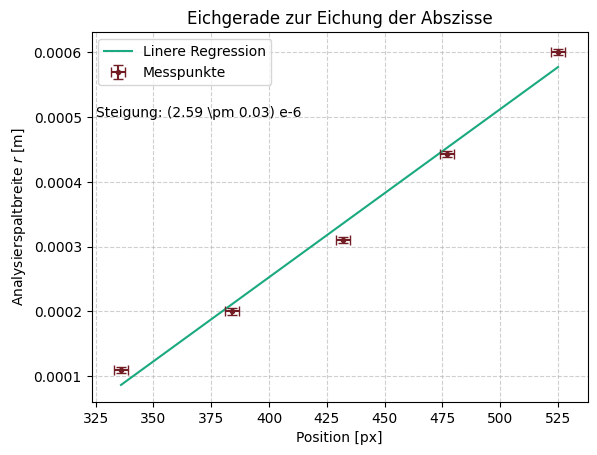

In [560]:
aufgabe = '2a'
folder = "./A2/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Tatsächliche Bestimmung der Eichung (Plot)
# --------------------------------------

# Lienare Regression 
def linear(x,a,b):
    return a*x+b

popt, pcov = curve_fit(linear, np.sort(pos_cur), np.sort(breite_anaSpalt),sigma = err_breite_anaSpalt, absolute_sigma = True)
eichung = popt[0]
err_eichung = np.sqrt(pcov[0,0])

plt.plot(
    np.sort(pos_cur), 
    linear(np.sort(pos_cur), *popt),
    label = "Linere Regression",
    color = hellgruen
    )

# Messpunkte mit Fehler
plt.errorbar(
    np.sort(pos_cur), np.sort(breite_anaSpalt),
    xerr = err_pos_cur,
    yerr = err_breite_anaSpalt, 
    linestyle='None',
    marker='.',
    label = "Messpunkte",
    color = weinrot,
    capsize=3.5
    )

plt.xlabel('Position [px]')
plt.ylabel('Analysierspaltbreite $r$ [m]')
plt.title('Eichgerade zur Eichung der Abszisse')
plt.grid(True, which="both", linestyle="--", alpha=0.6)

steig_eich = round_sig_digs(popt[0], err_eichung)

plt.text(325, 5e-4, f"Steigung: {steig_eich[2]}")

plt.legend()
print(f"Steigung: {popt[0]:.5g} \\pm {err_eichung:.1g} m/pixel")
plt.savefig(f"{safe_folder}Eichgerade{aufgabe}.pdf", dpi=300)

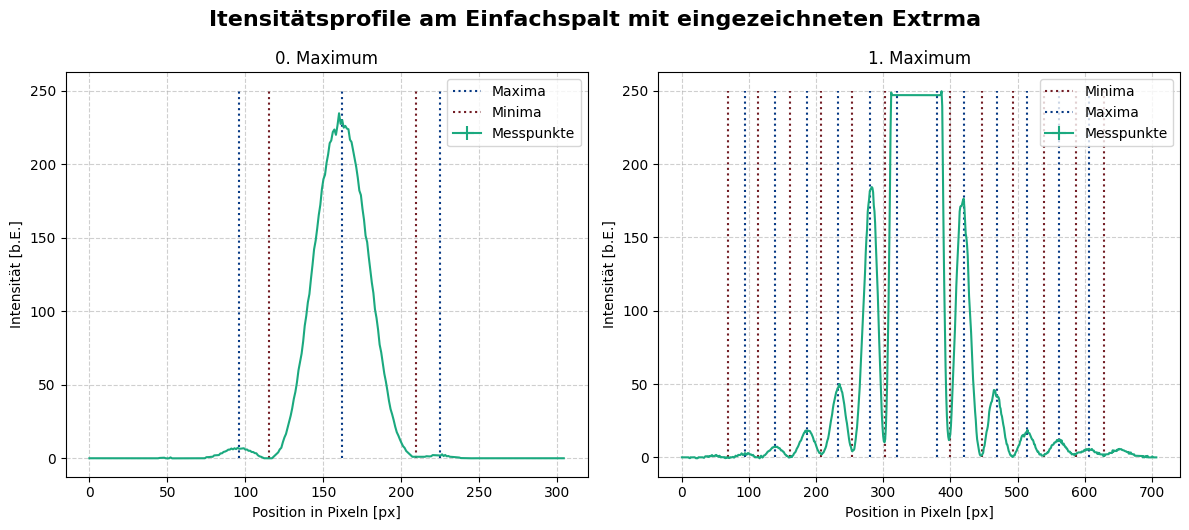

In [561]:
aufgabe = '2_Maxima'
folder = "./A2/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Bestimmung der Extrema
# --------------------------------------

#       -
#   Hauptmaximum
#       -
peak_hauptMax = signal.find_peaks_cwt(int_0Max, 5, noise_perc = 50)
peak_hauptMax = peak_hauptMax[2:5] # Wichtige herausfiltern
peak_pix_pos_hauptMax = pix_pos_hauptMax[peak_hauptMax[:]]

min_hauptMax = signal.find_peaks_cwt(-int_0Max, 22, noise_perc = 10)
min_pix_pos_hauptMax = pix_pos_hauptMax[min_hauptMax[:]]

# Plot mit Extrema
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(
    pix_pos_hauptMax,
    int_0Max,
    xerr=0,
    yerr=0,
    linestyle='-',
    marker=' ',
    label="Messpunkte",
    color=hellgruen,
    capsize=0
)

axes[0].vlines(
    x=peak_pix_pos_hauptMax,
    ymin=0,
    ymax=250,
    colors=blau,
    linestyles='dotted',
    label='Maxima'
)

axes[0].vlines(
    x=min_pix_pos_hauptMax,
    ymin=0,
    ymax=250,
    colors=weinrot,
    linestyles='dotted',
    label='Minima'
)


axes[0].set_xlabel('Position in Pixeln [px]')
axes[0].set_ylabel('Intensität [b.E.]')
axes[0].set_title('0. Maximum')
axes[0].grid(True, which="both", linestyle="--", alpha=0.6)
axes[0].legend()

#      ----
# 1. Maximum
#      ----

# Minima bestimmen
minima_nebenMax = signal.find_peaks_cwt(-intensity_nebenMax, 15)
minima_nebenMax = minima_nebenMax[1:13]
minima_pix_pos_nebenMax = pix_pos_nebenMax[minima_nebenMax]


# Maxima des 1. Maximums
peaks_nebenMax = signal.find_peaks_cwt(intensity_nebenMax,np.arange(10,40),noise_perc=25,)
peaks_nebenMax = np.concatenate((peaks_nebenMax[1:7],peaks_nebenMax[8:14]))
peaks_pix_pos_nebenMax = pix_pos_nebenMax[peaks_nebenMax]


# Plot des 1. Maximums
axes[1].errorbar(
    pix_pos_nebenMax,
    intensity_nebenMax,
    xerr=0,
    yerr=0,
    linestyle='-',
    marker=' ',
    label="Messpunkte",
    color=hellgruen,
    capsize=0
)

axes[1].vlines(
    x=minima_pix_pos_nebenMax,
    ymin=0,
    ymax=250,
    colors=weinrot,
    linestyles='dotted',
    label='Minima',  
)

axes[1].vlines(
    x=peaks_pix_pos_nebenMax,
    ymin=0,
    ymax=250,
    colors=blau,
    linestyles='dotted',
    label='Maxima'
)

axes[1].set_xlabel('Position in Pixeln [px]')
axes[1].set_ylabel('Intensität [b.E.]')
axes[1].set_title('1. Maximum')
axes[1].grid(True, which="both", linestyle="--", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.suptitle('Itensitätsprofile am Einfachspalt mit eingezeichneten Extrma', weight='bold', size='16', y=1.05)
plt.savefig(f"{safe_folder}Eingezeichnete_Positionen_Maxima_{aufgabe}.pdf", dpi=300, bbox_inches='tight')
plt.show()

Es wird das 1. Maximum betrachtet:

In [562]:
# Abstände zwischen den Maxima 
anzahl_minima = len(minima_nebenMax)
ord_minima = np.arange(-anzahl_minima//2, anzahl_minima//2 + 1)
ord_minima = np.delete(ord_minima, anzahl_minima//2) # Das mittlere Minimum wird gelöscht, da es um das Hauptmaximum liegt
center_pos = 0.5 * (peaks_pix_pos_nebenMax[anzahl_minima//2 - 1]
                    + peaks_pix_pos_nebenMax[anzahl_minima//2])

dist_min = np.concatenate([
    minima_pix_pos_nebenMax[:anzahl_minima//2] - center_pos,
    [0.0],
    minima_pix_pos_nebenMax[anzahl_minima//2:] - center_pos,
])


# Geschätzte Ungenauigkeiten
dist_err = 10

In [563]:
dist_min = np.diff(dist_min)
dist_err = 10

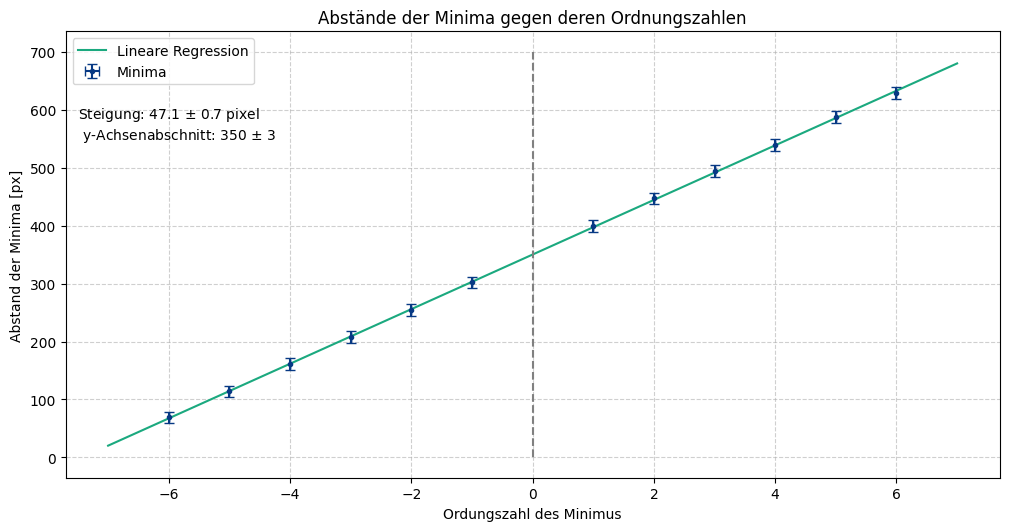

In [564]:
aufgabe = '2_full_range'
folder = "./A2/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Verbesserter Plot: Minima- und Maxima-Abstände (nach Ordnung) 
# --------------------------------------

# Lineare Regression 
def linear(x,a,b):
    return a*x+b

popt, pcov = curve_fit(linear, ord_minima, minima_pix_pos_nebenMax, sigma=dist_err, absolute_sigma = True)

steig_abst_Extrema = popt[0]
absch_abst_Extrema = popt[1]

err_absch_abst_Extrema = np.sqrt(pcov[1,1])
err_steig_abst_Extrema = np.sqrt(pcov[0,0])

steig  = round_sig_digs(steig_abst_Extrema, err_steig_abst_Extrema)
absch = round_sig_digs(absch_abst_Extrema, err_absch_abst_Extrema)

fig, axes = plt.subplots(1, figsize=(10, 5))

# Regression
x = np.linspace(-7,7)
plt.plot(
    x, 
    linear(x, *popt),
    label = "Lineare Regression",
    color = hellgruen
    )

plt.errorbar(
    ord_minima,
    minima_nebenMax,
    xerr=0,
    yerr=dist_err,
    linestyle='',
    marker='.',
    label="Minima",
    color=blau,
    capsize=3.5
)

plt.vlines(
    [0], 
    0, 
    700,
    linestyle='--',
    color='gray'
)

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.xlabel('Ordungszahl des Minimus')
plt.ylabel('Abstand der Minima [px]')
plt.title('Abstände der Minima gegen deren Ordnungszahlen')
plt.text(-7.5, 550, f"Steigung: {steig[0]} $\\pm$ {steig[1]} pixel \n y-Achsenabschnitt: {absch[0]} $\\pm$ {absch[1]}")
plt.savefig(f"{safe_folder}Minima_Ordnungszahl_{aufgabe}.pdf", dpi=300, bbox_inches='tight')
plt.show()

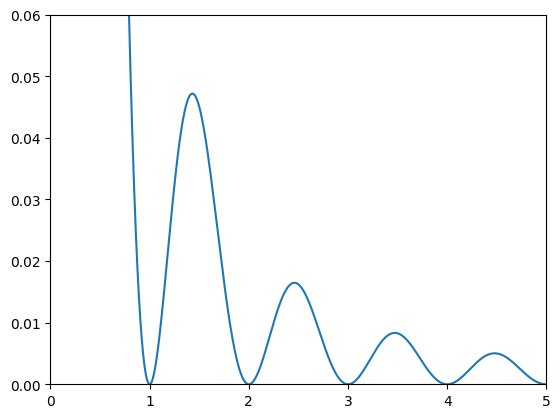

In [565]:
# --------------------------------------
#   Theoretische Position der Extrema
# --------------------------------------
def beugung_spalt(n):
    return np.sinc(n)**2

# Maxima dieser Funktion finden 
x = np.linspace(-7,7,10000)
y = beugung_spalt(x)
peaks_theo = signal.find_peaks_cwt(y, np.arange(0.1, 0.15))
pos_peaks_theo = np.zeros(anzahl_minima + 1)
pos_peaks_theo = x[peaks_theo]
pos_peaks_theo = pos_peaks_theo[1:-1]

plt.xlim(0,5)
plt.ylim(0,0.06)
plt.plot(x,y)


In [566]:
aufgabe = 'try2'
folder = "./A2/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Bestimmung der Maximaordnungszahlen
# --------------------------------------
# Lineare Regression 
def linear(x,a,b):
    return a*x+b

popt, pcov = curve_fit(linear, ord_minima, minima_pix_pos_nebenMax, sigma=dist_err, absolute_sigma = True)

steig_abst_Extrema = popt[0]
absch_abst_Extrema = popt[1]

err_steig_abst_Extrema = np.sqrt(pcov[0,0])
err_absch_abst_Extrema = np.sqrt(pcov[1,1])

steig  = round_sig_digs(steig_abst_Extrema, err_steig_abst_Extrema)
absch = round_sig_digs(absch_abst_Extrema, err_absch_abst_Extrema)

abstand, abschnitt, steigung = sp.symbols(r'{a_\text{max}}, b, m')
params=[abstand, abschnitt, steigung]

ordMaxFunc = (abstand - abschnitt)/steigung

values_ord_max_Func = [
    peaks_pix_pos_nebenMax, dist_err,
    absch_abst_Extrema, err_absch_abst_Extrema,
    steig_abst_Extrema, err_steig_abst_Extrema
]

res_ord = calc2 (ordMaxFunc, params, values_ord_max_Func, [], False)
ord_max_berechnet_full = res_ord[:,0]
err_ord_max_berechnet_full = res_ord[:,1]

mid = len(ord_max_berechnet_full) // 2
ord_max_berechnet = np.delete(ord_max_berechnet_full, [mid - 1, mid])
err_ord_max_berechnet = np.delete(err_ord_max_berechnet_full, [mid - 1, mid])

# print(pos_peaks_theo)
# print(ord_max_berechnet)

abw = sigma_abweichung(ord_max_berechnet, pos_peaks_theo, err_ord_max_berechnet)
print(abw)

[0.18560106 0.02223777 0.0288297  0.12636703 0.17572939 0.22346544
 0.26809452 0.11096088 0.06796344 0.1407904 ]


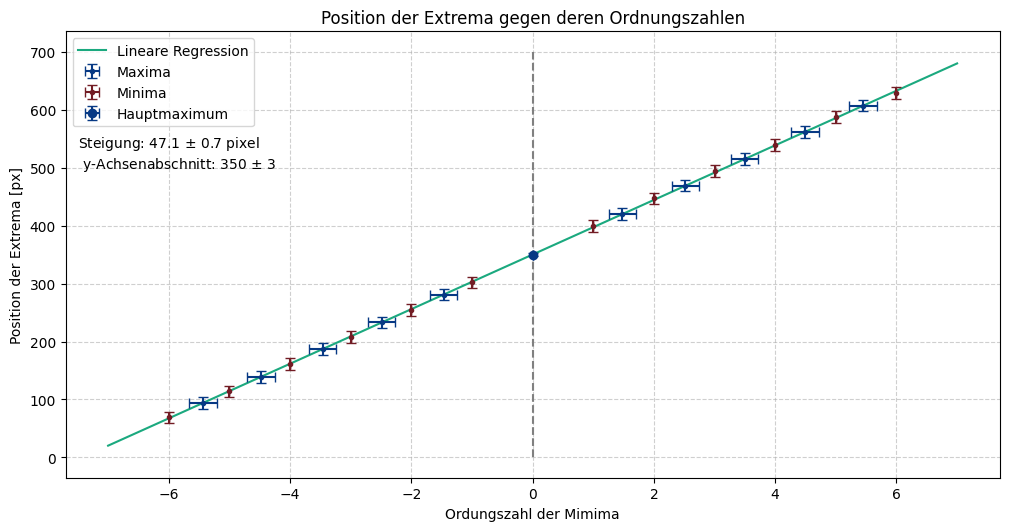

In [567]:
# --------------------------------------
#   Plotting
# --------------------------------------

fig, axes = plt.subplots(1, figsize=(10, 5))

# Regression
x = np.linspace(-7,7)
plt.plot(
    x, 
    linear(x, *popt),
    label = "Lineare Regression",
    color = hellgruen
    )

mid = len(peaks_nebenMax) // 2
peaks_nebenMax = np.delete(peaks_nebenMax, [mid - 1, mid])

# Maxima
plt.errorbar(
    ord_max_berechnet,
    peaks_nebenMax, 
    xerr = err_ord_max_berechnet, 
    yerr = dist_err,
    linestyle='None', 
    marker='.',
    label = "Maxima",
    color = blau,
    capsize=3.5
    )

# Minima
plt.errorbar(
    ord_minima,
    minima_nebenMax,
    xerr=0,
    yerr=dist_err,
    linestyle='',
    marker='.',
    label="Minima",
    color=weinrot,
    capsize=3.5
)

# Hauptmaximum
plt.errorbar(
    0,
    absch[0],
    xerr=0,
    yerr=absch[1],
    linestyle='',
    marker='o',
    label="Hauptmaximum",
    color=blau,
    capsize=3.5
)

plt.vlines(
    [0], 
    0, 
    700,
    linestyle='--',
    color='gray'
)

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.xlabel('Ordungszahl der Mimima')
plt.ylabel('Position der Extrema [px]')
plt.title('Position der Extrema gegen deren Ordnungszahlen')
plt.text(-7.5, 500, f"Steigung: {steig[0]} $\\pm$ {steig[1]} pixel \n y-Achsenabschnitt: {absch[0]} $\\pm$ {absch[1]}")
plt.savefig(f"{safe_folder}Extrema_Abstand_Ordnungszahl{aufgabe}.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [568]:
# --------------------------------------
#   Latex Export
# --------------------------------------

tab_header = [
            r'n_\text{{theo}}',
            r'n_\text{{exp}}',
            r'\text{{Std. Abw. }} \sigma',
        ]

table_row = []
for n in range(len(ord_max_berechnet)):  
    str_n_max = f'{ord_max_berechnet[n]:.2f} \\pm {err_ord_max_berechnet[n]:.2g}'

    table_row.append([pos_peaks_theo[n], str_n_max, abw[n]])

df = pd.DataFrame(
    table_row
)

latex_table = df.to_latex(
    index=False,
    escape=False,
    bold_rows=True,
    float_format="%.2f",
    header=tab_header,
    position = 'h!',
    column_format="L | C || C",
    caption=r'Vergleich der experimentell bestimmten Ordnungszahlen un der theorisch erwatreten.',
    label="tab:vergleich_ordnungszahl_theo_ex_einzelspalt"
)

print(latex_table)

\begin{table}[h!]
\caption{Vergleich der experimentell bestimmten Ordnungszahlen un der theorisch erwatreten.}
\label{tab:vergleich_ordnungszahl_theo_ex_einzelspalt}
\begin{tabular}{L | C || C}
\toprule
n_\text{theo} & n_\text{exp} & \text{Std. Abw. } \sigma \\
\midrule
-5.48 & -5.44 \pm 0.24 & 0.19 \\
-4.48 & -4.48 \pm 0.23 & 0.02 \\
-3.47 & -3.46 \pm 0.23 & 0.03 \\
-2.46 & -2.49 \pm 0.22 & 0.13 \\
-1.43 & -1.47 \pm 0.22 & 0.18 \\
1.43 & 1.48 \pm 0.22 & 0.22 \\
2.46 & 2.52 \pm 0.22 & 0.27 \\
3.47 & 3.50 \pm 0.23 & 0.11 \\
4.48 & 4.49 \pm 0.23 & 0.07 \\
5.48 & 5.45 \pm 0.24 & 0.14 \\
\bottomrule
\end{tabular}
\end{table}



In [569]:
# --------------------------------------
#   Einzelspaltbreite bestimmen
# --------------------------------------
f1_sym, lambda_sym, sc_sym, ss_sym= sp.symbols(r'{f_1}, \lambda, {s_\text{E}}, s')
params = [f1_sym, lambda_sym, sc_sym, ss_sym]

spaltBreit = 2 * f1_sym * lambda_sym/(sc_sym * ss_sym)

values_spaltBreit = [
    f_l1, 
    lam,
    eichung, err_eichung,
    steig_abst_Extrema, err_steig_abst_Extrema
    ]

ph = calc2(spaltBreit, params, values_spaltBreit, params_without_error = [f1_sym, lambda_sym], p_latex=False)
spaltBreit_M1 = ph[0][0]
err_spaltBreit_M1 = ph[0][1]
print('Spaltbreite ' + (round_sig_digs(spaltBreit_M1, err_spaltBreit_M1))[2])

Results:
[[6.96358084e-05 1.41850107e-06]]
Spaltbreite (6.96 \pm 0.14) e-5


## Bestimmung der Itensitäten
Es sollen die relativen Itensitäten bestimmt werden und mit den theoretischen Werten verglichen werden. Es müssen beide Messreihen zusammengefügt werden.

In [570]:
# --------------------------------------
#   Bestimmung der Theoretisch erwateten und gemessenen 
#   (relativen) Itensitäten
# --------------------------------------

#   Theoretisch  
rel_inten_theo = beugung_spalt(pos_peaks_theo)

# Geschätzter relativer Fehler der Intensitäten
err_rel_proz = 0.05  # 5%

#   Hauptmaximum (0. Ordnung)  
int0 = int_0Max[peak_hauptMax[1]]
err_int_0 = int0 * err_rel_proz

#   1. Ordnung  
abs_int_1 = np.zeros(2)
abs_int_1[0] = int_0Max[peak_hauptMax[0]] # Links
abs_int_1[1] = int_0Max[peak_hauptMax[2]] # Rechts

err_abs_int_1 = abs_int_1 * np.sqrt(2) * err_rel_proz

rel_int_1 = abs_int_1 / int0
err_rel_int_1 = rel_int_1 * err_rel_proz

# Messreihe 2
int_abs_M2 = np.zeros(12)
err_int_abs_M2 = np.zeros(12)

int_abs_M2 = intensity_nebenMax[peaks_nebenMax]
err_int_abs_M2 = int_abs_M2 * err_rel_proz

# Arithmetisches Mittel
int_abs_arim = np.zeros(5)
err_int_abs_arim = np.zeros(5)

for i in np.arange(0,5):
    int_abs_arim[4-i] = 0.5 * (int_abs_M2[i] + int_abs_M2[9-i])
    err_int_abs_arim[i] = int_abs_arim[i] * np.sqrt(2) * err_rel_proz

#Berechnung der Quotienten
int_rel_arim = int_abs_arim/int_abs_arim[0]
int_rel_arim = int_abs_arim/int0
err_int_rel_arim = int_rel_arim * np.sqrt(2) * err_rel_proz

int_rel_comb = np.zeros(6)
err_int_rel_comb = np.zeros(6)

int_rel_comb[0] = 1
err_int_rel_comb[0] = 0

int_rel_comb[1] = np.mean(rel_int_1)
err_int_rel_comb[1] = np.mean(err_rel_int_1)

#Finale Ergebnisse
for i in np.arange(0,5):
    int_rel_comb[i] = int_rel_arim[i] * np.mean(rel_int_1)
    err_int_rel_comb[i] = int_rel_comb[i] * 2 * err_rel_proz 

# print((rel_inten_theo))
# print(int_rel_comb)

int_rel_comb[5] = 0.002/8
err_int_rel_comb[5] =int_rel_comb[5] * 2 * err_rel_proz

print(f'Theoretisch zu erwarten: \n{np.sort(rel_inten_theo[0:6])} \n')
print(f'Experimentell: \n{np.sort(int_rel_comb)} \n')

print(f'Relative Abweichung: \n{(np.sort(int_rel_comb)/np.sort(rel_inten_theo[0:6]))} \n')

korr_term = np.mean((np.sort(rel_inten_theo[0:6]/np.sort(int_rel_comb))))
err_korr_term = np.std((np.sort(rel_inten_theo[0:6]/np.sort(int_rel_comb))))

print(f'Durchschnittliche Relative Abweichung: \n{korr_term} \\pm {err_korr_term} \n')

# print(f'Experimentelle ungenauigkeit: \n{np.sort(int_rel_comb)} \n')
# print(f'Standardabweichung der Itensitäten: \n{abw_inten}')


Theoretisch zu erwarten: 
[0.00336071 0.00502871 0.00834026 0.01648001 0.04719045 0.04719045] 

Experimentell: 
[0.00025    0.00033949 0.00070726 0.0014408  0.00345932 0.01397598] 

Relative Abweichung: 
[0.07438895 0.06751092 0.08480025 0.08742732 0.0733056  0.29616117] 

Durchschnittliche Relative Abweichung: 
11.417304829779987 \pm 3.7720870563928073 



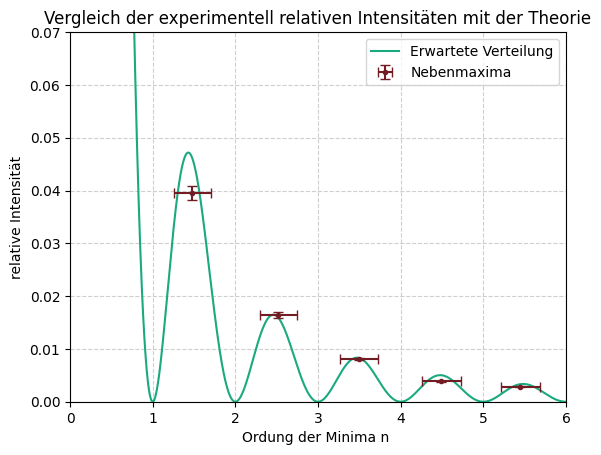

In [571]:
aufgabe = 'GesmateBreite_ex-theo'
folder = "./A2/"
safe_folder = "../img/plots/"

korr_int_rel_comb = int_rel_comb[1:] * korr_term
korr_err_int_rel_comb = err_int_rel_comb[1:] * err_korr_term

# --------------------------------------
#   Vergleichsplot: Experiment vs Theorie
# --------------------------------------
x = np.linspace(-7,7,10000)
y = beugung_spalt(x)

plt.plot(
    x,
    y,
    label="Erwartete Verteilung",
    color=hellgruen
    )

# print(len(ord_max_berechnet[4:]))
# print(len(int_rel_comb))
# print(int_rel_comb)

# Nebenmaxima nach Messreihe M2
plt.errorbar(
    ord_max_berechnet[5:],
    korr_int_rel_comb,
    xerr=err_ord_max_berechnet[5:], 
    yerr=korr_err_int_rel_comb,
    linestyle='None', 
    marker='.',
    label = "Nebenmaxima",
    color = weinrot,
    capsize=3.5
)

plt.ylim((0,0.07))
plt.xlim((0,6))
plt.xlabel("Ordung der Minima n ")
plt.ylabel("relative Intensität")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.title('Vergleich der experimentell relativen Intensitäten mit der Theorie')
plt.savefig(f"{safe_folder}relative-Intensität{aufgabe}.pdf", dpi=300)

In [572]:
# ----------------------------------------------------------------------
#   Verbesserte relative Intensitäten (korrigiert)
# ----------------------------------------------------------------------

# Theoretisch  
rel_inten_theo = beugung_spalt(pos_peaks_theo) # sinc^2
print(f'Theoretisch zu erwarten:\n{rel_inten_theo[0:5]}\n')

# Geschätzter relativer Fehler
err_rel_proz = 0.05  # 5%

#   Hauptmaximum  
int0 = int_0Max[peak_hauptMax[1]]
err_int_0 = int0 * err_rel_proz

# 1. Nebenmaximum (Messreihe 1)  
abs_int_1 = np.array([
    int_0Max[peak_hauptMax[0]],  # links
    int_0Max[peak_hauptMax[2]]   # rechts
])

abs_int_1_arim = np.mean(abs_int_1)

# Fehler des Mittels (korrekt!)
err_abs_int_1 = abs_int_1_arim * err_rel_proz / np.sqrt(2)

rel_int_1 = abs_int_1_arim / int0

# Fehlerfortpflanzung für Quotient
err_rel_int_1 = rel_int_1 * np.sqrt(
    (err_abs_int_1 / abs_int_1_arim)**2 +
    (err_int_0 / int0)**2
)

# Messreihe 2  
int_abs_M2 = intensity_nebenMax[peaks_nebenMax]
err_int_abs_M2 = int_abs_M2 * err_rel_proz

# Mittelung links/rechts  
int_abs_arim = np.zeros(5)
err_int_abs_arim = np.zeros(5)

for i in range(5):
    links = int_abs_M2[i]
    rechts = int_abs_M2[9 - i]

    int_abs_arim[i] = 0.5 * (links + rechts)

    # Fehler des Mittels
    err_int_abs_arim[i] = int_abs_arim[i] * err_rel_proz / np.sqrt(2)

# Skalierung über 1. Nebenmaximum  
# print(int_abs_arim)
skal = abs_int_1_arim / int_abs_arim[4]

korr_int_abs = int_abs_arim * skal
korr_err_int_abs = err_int_abs_arim * skal

# Normierung auf Hauptmaximum  
rel_inten_final = korr_int_abs / int0

# Fehlerfortpflanzung (Quotient!)
err_rel_inten_final = rel_inten_final * np.sqrt(
    (korr_err_int_abs / korr_int_abs)**2 +
    (err_int_0 / int0)**2
)

print("Experimentelle relative Intensitäten:")
print(rel_inten_final)

print("\nFehler:")
print(err_rel_inten_final)

sig_abw_korrrr = sigma_abweichung(
    rel_inten_theo[0:5],
    rel_inten_final,
    err_rel_inten_final
)

print("\nSigma-Abweichungen:")
print(sig_abw_korrrr)


print(rel_inten_theo[:5] - rel_inten_final)
print((rel_inten_final / rel_inten_theo[:5]) * 100)

Theoretisch zu erwarten:
[0.00336071 0.00502871 0.00834026 0.01648001 0.04719045]

Experimentelle relative Intensitäten:
[0.00043491 0.00090603 0.00184573 0.00443155 0.01790386]

Fehler:
[2.66324155e-05 5.54825913e-05 1.13027652e-04 2.71375953e-04
 1.09638306e-03]

Sigma-Abweichungen:
[109.8589278   74.30585291  57.45961023  44.39766395  26.71200305]
[0.00292581 0.00412268 0.00649452 0.01204846 0.02928659]
[12.94086633 18.01709083 22.1304147  26.890463   37.93958553]


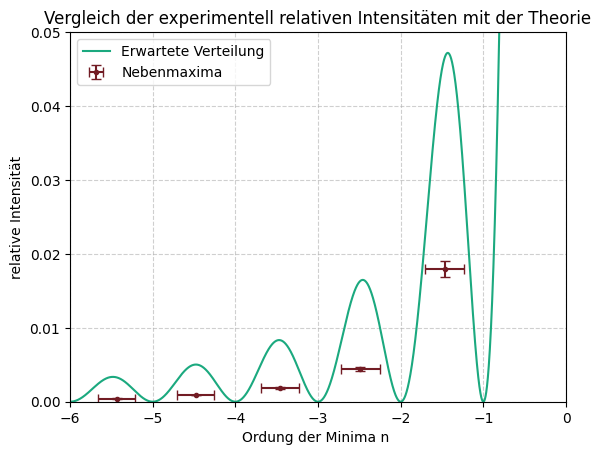

In [573]:
aufgabe = 'neu'
folder = "./A2/"
safe_folder = "../img/plots/"

korr_int_rel_comb = int_rel_comb[1:] * korr_term
korr_err_int_rel_comb = err_int_rel_comb[1:] * err_korr_term

# --------------------------------------
#   Vergleichsplot: Experiment vs Theorie
# --------------------------------------
x = np.linspace(-7,7,10000)
y = beugung_spalt(x)

plt.plot(
    x,
    y,
    label="Erwartete Verteilung",
    color=hellgruen
    )

# Nebenmaxima nach Messreihe M2
plt.errorbar(
    ord_max_berechnet[:5],
    rel_inten_final,
    xerr=err_ord_max_berechnet[5:], 
    yerr=err_rel_inten_final,
    linestyle='None', 
    marker='.',
    label = "Nebenmaxima",
    color = weinrot,
    capsize=3.5
)

plt.ylim((0,0.05))
plt.xlim((-6,0))
plt.xlabel("Ordung der Minima n ")
plt.ylabel("relative Intensität")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.title('Vergleich der experimentell relativen Intensitäten mit der Theorie')
plt.savefig(f"{safe_folder}relative-Intensität{aufgabe}.pdf", dpi=300)

In [574]:
# ----------------------------------------------------------------------
#   Verbesserter Latex Export
# ----------------------------------------------------------------------


n = 5

rel_inten_str = []
abweichungen_des_sigmas_lol = []


for i in range(n):
    rel_inten_str.append(f'{rel_inten_final[i] * 1e2:.4f} \\pm {err_rel_inten_final[i] * 1e2:.4f}')
    abweichungen_des_sigmas_lol.append(f'{sig_abw_korrrr[i]:.2f}')

df = pd.DataFrame({
    "\\text{Maximum}": np.arange(1, n+1),
    "\\text{Theorie} \\cdot 10^{2}": rel_inten_theo[:n] * 1e2,
    "\\text{Experiment} \\cdot 10^{2}": rel_inten_str[:n],
    "\\text{Diff (Theo - Ex)} \\cdot 10^{2}": rel_inten_final[:n] * 1e2 - rel_inten_theo[:n] * 1e2,
    "Abw. [\\%]": (1 - (rel_inten_final[:n] / rel_inten_theo[:n])) * 100,
    "\\text{Std.Abw. } \\sigma": abweichungen_des_sigmas_lol[:n]
})

latex_table = df.to_latex(
    index=False,
    float_format="%.3f",
    caption="Relative Intensitäten: Theorie vs. Experiment",
    label="tab:intensitaeten",
    column_format="C | C C || C | C | C"
)

print(latex_table)

\begin{table}
\caption{Relative Intensitäten: Theorie vs. Experiment}
\label{tab:intensitaeten}
\begin{tabular}{C | C C || C | C | C}
\toprule
\text{Maximum} & \text{Theorie} \cdot 10^{2} & \text{Experiment} \cdot 10^{2} & \text{Diff (Theo - Ex)} \cdot 10^{2} & Abw. [\%] & \text{Std.Abw. } \sigma \\
\midrule
1 & 0.336 & 0.0435 \pm 0.0027 & -0.293 & 87.059 & 109.86 \\
2 & 0.503 & 0.0906 \pm 0.0055 & -0.412 & 81.983 & 74.31 \\
3 & 0.834 & 0.1846 \pm 0.0113 & -0.649 & 77.870 & 57.46 \\
4 & 1.648 & 0.4432 \pm 0.0271 & -1.205 & 73.110 & 44.40 \\
5 & 4.719 & 1.7904 \pm 0.1096 & -2.929 & 62.060 & 26.71 \\
\bottomrule
\end{tabular}
\end{table}



In [575]:
# --------------------------------------
#   Latex-Export und StdAbweichung der relativen Intensitäten
# --------------------------------------

# Ordnungszahlen
m = ord_max_berechnet[5:]

# Theoretische Intensitäten (anpassen falls Länge anders)
I_theo = rel_inten_theo[:5]

# Experimentelle Intensitäten
I_exp = korr_int_rel_comb[:5]
err_I_exp = korr_err_int_rel_comb[:5]


exp_str = []
for i in range(len(I_exp)):
    exp_str.append(f'{I_exp[len(I_exp) -1 - i] * 100:.3f} \\pm {err_I_exp[len(I_exp) -1 - i]* 100:.1g}')

# Standardabweichung
sigma = sigma_abweichung(np.sort(I_theo), np.sort(I_exp), np.sort(err_I_exp))

# print(np.sort(I_theo), np.sort(I_exp), np.sort(err_I_exp))

df = pd.DataFrame({
    r'\text{Ordnungszahl} m': m,
    r'\text{theo} I_\text{rel} 10^{3}': np.sort(I_theo) * 100,
    r'\text{exp} I_\text{rel} 10^{3}': exp_str,
    r'\text{Std.Abw.} \sigma': sigma
})

latex_table = df.to_latex(
    index=False,
    float_format="%.2f",
    column_format='C C C C',
    caption="Vergleich von theoretischen und experimentellen Intensitäten",
    label="tab:intensitaeten",
    escape=False
)

print(latex_table)

\begin{table}
\caption{Vergleich von theoretischen und experimentellen Intensitäten}
\label{tab:intensitaeten}
\begin{tabular}{C C C C}
\toprule
\text{Ordnungszahl} m & \text{theo} I_\text{rel} 10^{3} & \text{exp} I_\text{rel} 10^{3} & \text{Std.Abw.} \sigma \\
\midrule
1.48 & 0.34 & 0.285 \pm 0.009 & 5.37 \\
2.52 & 0.50 & 0.388 \pm 0.01 & 9.00 \\
3.50 & 0.83 & 0.807 \pm 0.03 & 0.99 \\
4.49 & 1.65 & 1.645 \pm 0.05 & 0.06 \\
5.45 & 4.72 & 3.950 \pm 0.1 & 5.90 \\
\bottomrule
\end{tabular}
\end{table}



# Spaltbreite am Einzelspalt (A4)

In [576]:
# --------------------------------------
#   Experimentdaten für die Spaltbreite
# --------------------------------------

# Brennweite der Linse von mm in m
f1 = 80e-3

# Bildweite b von cm in m
b_weit = 35.0e-2
err_b_weit = 0.5e-2

# Objektabstand zur Linse L1 von mm in m
obj_abst = 115e-3
err_obj_abst = 0.5e-3

# Spaltbreite des Analysespaltes von mm in m
anaSpalt_breit = np.array([0.110, 0.286, 0.420, 0.649, 18.975]) * 1e-3
err_anaSpalt_breit = 0.5e-6

# Kamera Pixelauflösung nach Praktikumsskipt umgerechnet in m/px
px_breit = 3.45e-6

# Fehlender Wert der Spaltbreite Einzelspalt in px 
pix_breit_1S = 360.2
err_pix_breit_1S = 3

In [577]:
pix_breit_1S * px_breit 

0.0012426899999999999

In [578]:
aufgabe = 'GesmateBreite_ex-theo'
folder = "./A4/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Einlesen der Textdateien
# --------------------------------------

# Daten für das 0. Hauptmaximum
pix_pos_0, int_0 = np.loadtxt(f'{folder}0-Maximum', unpack=True)

# Daten bis zum 1. Nebenmaximum
pix_pos_1, int_1 = np.loadtxt(f'{folder}1-Maximum', unpack=True)


# Daten bis zum 2. Nebenmaximum
pix_pos_2, int_2 = np.loadtxt(f'{folder}2-Maximum', unpack=True)


# Daten bis zum 3. Nebenmaximum
pix_pos_3, int_3 = np.loadtxt(f'{folder}3-Maximum', unpack=True)


# Daten bis alle Nebenmaxima zu sehen sind
pix_pos_all, int_all = np.loadtxt(f'{folder}Voll-Offen', unpack=True)
# pix_pos_all, int_all = np.loadtxt(f'{folder}Voll-Offen-Schoener', unpack=True)


In [579]:
# # --------------------------------------
# #   Plotten der Messdaten
# # --------------------------------------

# fig = plt.figure(figsize=(9, 8))
# gs = fig.add_gridspec(3, 2)

# ax0 = fig.add_subplot(gs[0, 0])
# ax1 = fig.add_subplot(gs[0, 1])
# ax2 = fig.add_subplot(gs[1, 0])
# ax3 = fig.add_subplot(gs[1, 1])
# ax_all = fig.add_subplot(gs[2, :])

# axes = [ax0, ax1, ax2, ax3, ax_all]

# ax0.plot(pix_pos_0, int_0, color=gruen)
# ax0.set_title("0. Maximum")

# ax1.plot(pix_pos_1, int_1, color=gruen)
# ax1.set_title("1. Maximum")

# ax2.plot(pix_pos_2, int_2, color=gruen)
# ax2.set_title("2. Maximum")

# ax3.plot(pix_pos_3, int_3, color=gruen)
# ax3.set_title("3. Maximum")

# ax_all.plot(pix_pos_all, int_all, color=gruen)
# ax_all.set_title("Alle Ordnungen")

# lims = {
#     ax0: ((100, 650), (0, 800)),
#     ax1: ((100, 650), (0, 800)),
#     ax2: ((100, 650), (0, 800)),
#     ax3: ((100, 650), (0, 800)),
#     ax_all: ((150, 550), (0, 1000)),
# }

# for ax, (xlim, ylim) in lims.items():
#     ax.set_xlabel("Pixelposition [b.E.]")
#     ax.set_ylabel("Intensität [px]")
#     ax.set_xlim(*xlim)
#     ax.set_ylim(*ylim)
#     ax.grid(True, which="both", linestyle="--", alpha=0.6)

# fig.suptitle("Untersuchte Messreihen bis zu angegebenen Maxima", fontsize=18, weight='bold')
# plt.tight_layout(rect=[0, 0, 1, 0.99])

# plt.savefig(f"{safe_folder}Signale_{aufgabe}.pdf", dpi=300)
# plt.show()

In [580]:
# --------------------------------------
#   Anpassen der Verschiebung der Messdaten
# --------------------------------------

int_0 = int_0 - np.min(int_0)
int_1 = int_1 - np.min(int_1)
int_2 = int_2 - np.min(int_2)
int_3 = int_3 - np.min(int_3)
int_all = int_all - abs(np.min(int_all))

In [581]:
# # --------------------------------------
# #   Plotten der Messdaten
# # --------------------------------------

# fig = plt.figure(figsize=(9, 8))
# gs = fig.add_gridspec(3, 2)

# ax0 = fig.add_subplot(gs[0, 0])
# ax1 = fig.add_subplot(gs[0, 1])
# ax2 = fig.add_subplot(gs[1, 0])
# ax3 = fig.add_subplot(gs[1, 1])
# ax_all = fig.add_subplot(gs[2, :])

# axes = [ax0, ax1, ax2, ax3, ax_all]

# ax0.plot(pix_pos_0, int_0, color=gruen)
# ax0.set_title("0. Maximum")

# ax1.plot(pix_pos_1, int_1, color=gruen)
# ax1.set_title("1. Maximum")

# ax2.plot(pix_pos_2, int_2, color=gruen)
# ax2.set_title("2. Maximum")

# ax3.plot(pix_pos_3, int_3, color=gruen)
# ax3.set_title("3. Maximum")

# ax_all.plot(pix_pos_all, int_all, color=gruen)
# ax_all.set_title("Alle Ordnungen")

# lims = {
#     ax0: ((100, 650), (0, 800)),
#     ax1: ((100, 650), (0, 800)),
#     ax2: ((100, 650), (0, 800)),
#     ax3: ((100, 650), (0, 800)),
#     ax_all: ((50, 400), (0, 1000)),
# }

# for ax, (xlim, ylim) in lims.items():
#     ax.set_xlabel("Pixelposition [px]")
#     ax.set_ylabel("Intensität [b.E.]")
#     ax.set_xlim(*xlim)
#     ax.set_ylim(*ylim)
#     ax.grid(True, which="both", linestyle="--", alpha=0.6)

# fig.suptitle("Untersuchte Messreihen bis zu angegebenen Maxima", fontsize=18, weight='bold')
# plt.tight_layout(rect=[0, 0, 1, 0.99])

# plt.savefig(f"{safe_folder}Signale_OffsetKorr_{aufgabe}.pdf", dpi=300)
# plt.show()

In [582]:
# --------------------------------------
#   Anpassen der relativen intensitäten der Messdaten
# --------------------------------------

max_int_0 = max(int_0)

int_0 = int_0 / max_int_0
int_1 = int_1 / max_int_0 
int_2 = int_2 / max_int_0 
int_3 = int_3 / max_int_0
int_all = int_all / max_int_0

In [583]:
# # --------------------------------------
# #   Plotten der Messdaten
# # --------------------------------------

# fig = plt.figure(figsize=(9, 8))
# gs = fig.add_gridspec(3, 2)

# ax0 = fig.add_subplot(gs[0, 0])
# ax1 = fig.add_subplot(gs[0, 1])
# ax2 = fig.add_subplot(gs[1, 0])
# ax3 = fig.add_subplot(gs[1, 1])
# ax_all = fig.add_subplot(gs[2, :])

# axes = [ax0, ax1, ax2, ax3, ax_all]

# ax0.plot(pix_pos_0, int_0, color=gruen)
# ax0.set_title("0. Maximum")

# ax1.plot(pix_pos_1, int_1, color=gruen)
# ax1.set_title("1. Maximum")

# ax2.plot(pix_pos_2, int_2, color=gruen)
# ax2.set_title("2. Maximum")

# ax3.plot(pix_pos_3, int_3, color=gruen)
# ax3.set_title("3. Maximum")

# ax_all.plot(pix_pos_all, int_all, color=gruen)
# ax_all.set_title("Alle Ordnungen")

# lims = {
#     ax0: ((100, 650), (0, 1.5)),
#     ax1: ((100, 650), (0, 1.5)),
#     ax2: ((100, 650), (0, 1.5)),
#     ax3: ((100, 650), (0, 1.5)),
#     ax_all: ((50, 400), (0, 1.75)),
# }

# for ax, (xlim, ylim) in lims.items():
#     ax.set_xlabel("Pixelposition [px]")
#     ax.set_ylabel("relative Intensität")
#     ax.set_xlim(*xlim)
#     ax.set_ylim(*ylim)
#     ax.grid(True, which="both", linestyle="--", alpha=0.6)

# fig.suptitle("Untersuchte Messreihen bis zu angegebenen Maxima", fontsize=18, weight='bold')
# plt.tight_layout(rect=[0, 0, 1, 0.99])

# plt.savefig(f"{safe_folder}Signale_OffsetKorr_relativ_{aufgabe}.pdf", dpi=300)
# plt.show()

In [584]:
# --------------------------------------#  
#  Calc Einzelspalt Breite (M1: nutzung der Bildweite)
# --------------------------------------
b_sym, B_sym, f_sym, mu_sym = sp.symbols(r'b, {B_\text{d}}, {f_1}, \mu')
params = [b_sym , B_sym, f_sym, mu_sym]

G_func = f_sym * B_sym * mu_sym / (b_sym - f_sym)

values = np.array([
    b_weit, err_b_weit,
    pix_breit_1S, err_pix_breit_1S, # Die Werte stimmen so nicht... Es wurde Beispielwert eingetragen
    f1,
    px_breit
])

G_b = calc2(G_func, params, values, [f_sym, mu_sym], p_latex=False)
spaltbreit_einzel = G_b[0][0]
err_spaltbreit_einzel = G_b[0][1]

# --------------------------------------#   
# Calc Einzelspalt Breite (M2: nutzung der Gegenstandweite)
# --------------------------------------
g_sym , B_sym, f_sym, mu_sym = sp.symbols(r'g, {B_\text{d}}, {f_1}, \mu')
params = [g_sym , B_sym, f_sym, mu_sym]

G_func = B_sym * mu_sym / f_sym * (g_sym - f_sym)

values = np.array([
    obj_abst, err_obj_abst,
    pix_breit_1S, err_pix_breit_1S,
    f1,
    px_breit
])

G_g = calc2(G_func, params, values, [f_sym, mu_sym], p_latex=False)

sigma_abweichung(G_b[0][0], G_g[0][0], G_b[0][1], G_g[0][1])

Results:
[[3.68204444e-04 7.47648056e-06]]
Results:
[[5.43676875e-04 8.99040001e-06]]


np.float64(15.006687535137283)

In [585]:
# print(lam)
# print(f1)
# print(steig_eich[0])
# print(steig_abst_Extrema)

d_alt = lam * f1 /(float(steig_eich[0]) * steig_abst_Extrema)

lam_sym, f1_sym, s_e_sym, s_ord_sym = sp.symbols(r'\lambda, {f_1}, {s_\text{e}}, {s_\text{ord}}')
params = [s_e_sym, s_ord_sym, lam_sym, f1_sym]

func = (lam_sym * f1_sym )/(s_e_sym * s_ord_sym)

values = [
    float(steig_eich[0]), float(steig_eich[1]),
    steig_abst_Extrema, err_steig_abst_Extrema,
    lam,
    f1
]

calc2(func, params, values, [lam_sym, f1_sym], False)

print('Abweichung zu b')
print(sigma_abweichung(G_b[0][0],d_alt, G_b[0][1], d_alt))

print('Abweichung zu b')
print(sigma_abweichung(G_g[0][0],d_alt, G_g[0][1], d_alt))

Results:
[[3.48826082e-05 6.81561610e-07]]
Abweichung zu b
9.343331288862428
Abweichung zu b
14.12432928403727


## Funktionen für die Analyse erstellen

In [586]:
# --------------------------------------
#   Theoretische Vorhersage am Einzelspalt
# --------------------------------------
 
def synthese_einzelspalt(d, n):
    def spalt(k, y):
        return d/np.pi * np.sin(k*d/2)/(k*d/2) * np.cos(y*k)
        
    Y = np.linspace(-1,1,200)*d
    f_modifiziert = []
    for i in range(len(Y)):
        y = Y[i]
        result, error = quad(spalt, 0, 2*np.pi*n/d, args=(y,))
        f_modifiziert.append(result**2)
    # Normierung
    norm = np.float64(1.39)
    f_modifiziert = f_modifiziert / norm
    return Y, f_modifiziert

In [587]:
# --------------------------------------
# Breite anpassen (FWHM-Skalierung)
# --------------------------------------
def fwhm(x, y):
    half_max = np.max(y)/2
    # Interpolation für genauere Breite
    f = interp1d(x, y - half_max, kind='linear')
    roots = []
    for i in range(len(x)-1):
        if (y[i] - half_max) * (y[i+1] - half_max) < 0:
            # Nullstelle zwischen x[i] und x[i+1]
            roots.append(x[i] - (y[i]-half_max)*(x[i+1]-x[i])/(y[i+1]-y[i]))
    return np.abs(roots[-1] - roots[0])

## Hauptmaximum

In [588]:
# --------------------------------------
#   Vergleich des experimentellen Hauptmaximums mit der theorie
# --------------------------------------
# --- Experimentelle Werte ---
# Hauptmaximum finden
max_idx_0 = signal.find_peaks_cwt(int_0, widths=[100])
max_pix_exp = pix_pos_0[max_idx_0]

# Zentrisch ausrichten
pix_pos_0_zentrisch = pix_pos_0 - max_pix_exp

# pix_breit_1S = 112 Dieser Wert wurde leider (noch) nicht richtig bestimmt...
 
# --- Theorie Werte ---
Y_theo_0, int_theo_0 = synthese_einzelspalt(pix_breit_1S, 1)
theo_max_idx_0 = signal.find_peaks(int_theo_0)[0]
theo_max_pos_0 = Y_theo_0[theo_max_idx_0[0]]

# Skalierung der x-Achse
fwhm_theo = fwhm(Y_theo_0, int_theo_0)
fwhm_exp = fwhm(pix_pos_0_zentrisch, int_0)

scale = fwhm_theo / fwhm_exp
pix_pos_0_scaled = pix_pos_0_zentrisch * scale

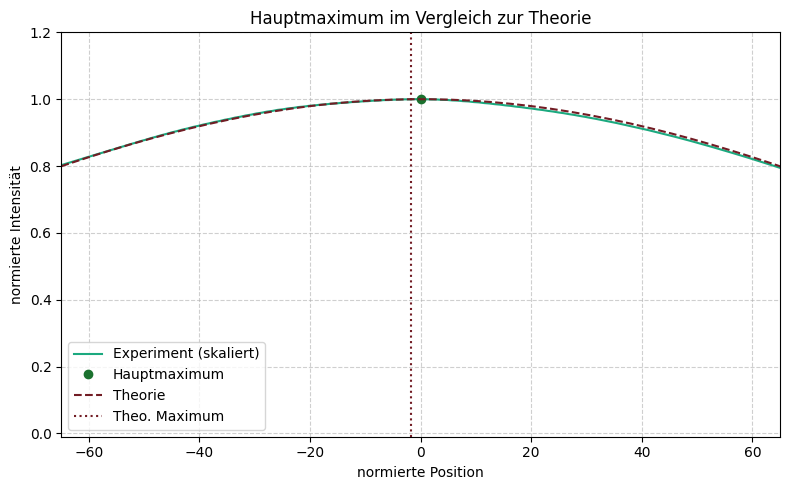

In [589]:
aufgabe = '3a'
folder = "./A4/"
safe_folder = "../img/plots/"

# --------------------------------------
# Plot
# --------------------------------------
plt.figure(figsize=(8,5))

# Messwerte
plt.plot(
    pix_pos_0_scaled, 
    int_0, 
    label='Experiment (skaliert)', 
    color=hellgruen
    )

# Experimentelles Maximum markieren
plt.plot(
    0, 
    1, 
    'o', 
    color=gruen, 
    label='Hauptmaximum'
    )

# Theoretischer Verlauf
plt.plot(
    Y_theo_0, 
    int_theo_0, 
    label='Theorie', 
    color=weinrot, 
    linestyle='--'
    )

# Theoretisches Maximum markieren
plt.axvline(
    x=theo_max_pos_0, 
    color=weinrot, 
    linestyle=':', 
    label='Theo. Maximum'
    )

plt.xlabel('normierte Position')
plt.ylabel('normierte Intensität')
plt.title('Hauptmaximum im Vergleich zur Theorie')
plt.legend()
plt.xlim((-65,65))
plt.ylim((-0.01,1.2))
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f'{safe_folder}H_Max_{aufgabe}.pdf')
plt.show()

## 1. Nebenmaximum

In [590]:
# --------------------------------------
#   Vergleich des der Maxima bis zur 1. Ordnung mit der theorie
# --------------------------------------
# --- Experimentelle Werte ---
# Maxima finden
max_idx_1, _ = signal.find_peaks(int_1, prominence=0.1, distance=50)
max_pix_exp_1 = pix_pos_1[max_idx_1] # expilziter Wert

print(f'Maxima pxPos: {max_idx_1}')

# Minima finden
min_idx_1 = signal.find_peaks(-int_1[220:580], distance=300)[0] + 220
min_pix_exp_1 = pix_pos_1[min_idx_1[0]]
print(f'Minima pxPos: {min_idx_1}')

# Zentrisch asurichten
pix_pos_1_zentrisch = pix_pos_1 - min_pix_exp_1 

# --- Theorie Werte ---
Y_theo_1, int_theo_1 = synthese_einzelspalt(pix_breit_1S, 2)
theo_max_idx_1 = signal.find_peaks(int_theo_1)[0]
print(theo_max_idx_1)
theo_max_pos_1 = Y_theo_1[theo_max_idx_1[1:3]]

# Skaling
fwhm_theo = fwhm(Y_theo_1, int_theo_1)
fwhm_exp = fwhm(pix_pos_1_zentrisch, int_1)

scale = fwhm_theo / fwhm_exp

pix_pos_1_scaled = pix_pos_1_zentrisch * scale
max_pix_exp_1_scaled = (max_pix_exp_1 - min_pix_exp_1) * scale


Maxima pxPos: [331 482]
Minima pxPos: [416]
[ 25  75 124 174]


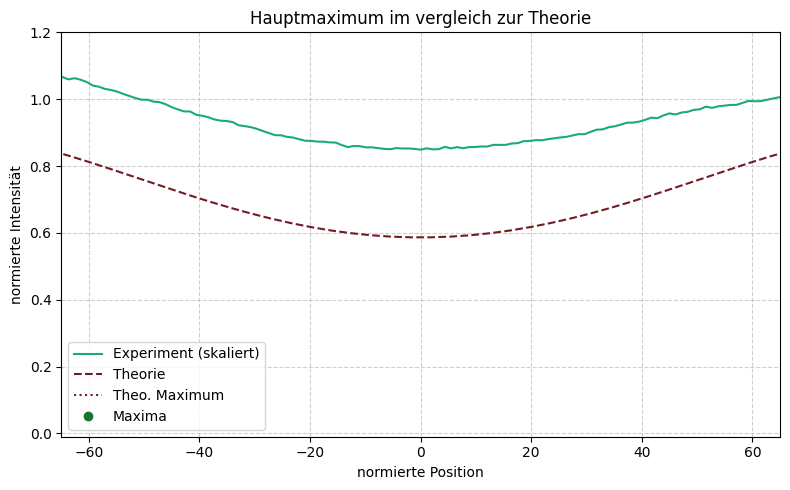

In [591]:
aufgabe = '3a'
folder = "./A4/"
safe_folder = "../img/plots/"

# --------------------------------------
# Plot
# --------------------------------------
plt.figure(figsize=(8,5))

# Messwerte
plt.plot(
    pix_pos_1_scaled, 
    int_1, 
    label='Experiment (skaliert)', 
    color=hellgruen
    )

# Experimentelles Maximum markieren
plt.errorbar(
    x = max_pix_exp_1_scaled,  
    y = int_1[max_idx_1], 
    errx = None,
    erry = None,
    fmt = 'o', 
    color=gruen, 
    label='Maxima'
    )

# Theoretischer Verlauf
plt.plot(
    Y_theo_1, 
    int_theo_1, 
    label='Theorie', 
    color=weinrot, 
    linestyle='--'
    )

# Theoretisches Maximum markieren
plt.vlines(
    x=theo_max_pos_1, 
    ymax = 1.2,
    ymin = 0, 
    color=weinrot, 
    linestyle=':', 
    label='Theo. Maximum'
    )

plt.xlabel('normierte Position')
plt.ylabel('normierte Intensität')
plt.title('Hauptmaximum im vergleich zur Theorie')
plt.legend()
plt.xlim((-65,65))
plt.ylim((-0.01,1.2))

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f'{safe_folder}1_Max_{aufgabe}.pdf')
plt.show()

## 2. Nebenmaximum

In [592]:
# --------------------------------------
#   Vergleich des experimentellen Hauptmaximums mit der theorie
# --------------------------------------
 
# Maxima finden
maxima_2 = signal.find_peaks_cwt(int_2, 40, noise_perc = 20)
print(f'Maxima pxPos: {maxima_2}')

# Minima finden
minima_2 = signal.find_peaks_cwt(-int_2[200:500], 20, noise_perc = 20) +200
print(f'Minima pxPos: {minima_2}')

# Gleich ausrichten
pix_pos_2_zentrisch = pix_pos_2 - maxima_2[1]

# Theoretisches Maxima finden
theo_maxima_2 = signal.find_peaks(synthese_einzelspalt(pix_breit_1S,3)[1], height=0.5)[0]
print(f'theoretische Maxima pxPos: {theo_maxima_2}')

# Theoretische Minima finden
theo_minima_2 = signal.find_peaks(-synthese_einzelspalt(pix_breit_1S,3)[1],height = -1)[0]
theo_minima_2 = theo_minima_2[3:5] # Nur mittlers elemente
print(f'theoretische Minima pxPos: {theo_minima_2}')


Maxima pxPos: [250 366 471]
Minima pxPos: [305 418]
theoretische Maxima pxPos: [ 66 100 133]
theoretische Minima pxPos: [ 83 116]


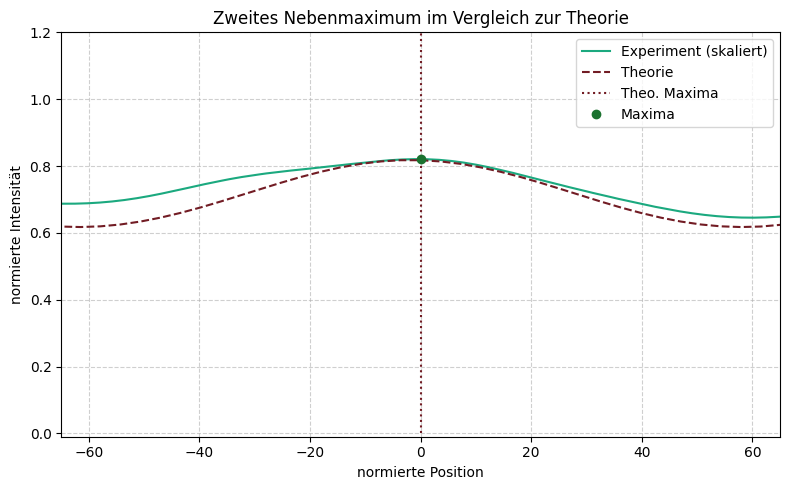

In [593]:
aufgabe = '3a'
folder = "./A4/"
safe_folder = "../img/plots/"

# Theoretische Werte
Y_theo_2, int_theo_2 = synthese_einzelspalt(pix_breit_1S, 3)

# mittleres Maximum als Referenz (wichtig!)
center_exp = maxima_2[1]
pix_pos_2_zentrisch = pix_pos_2 - pix_pos_2[center_exp]

# Theorie ebenfalls zentrieren (mittleres Maximum bestimmen)
theo_center_idx = theo_maxima_2[1]
Y_theo_2_zentrisch = Y_theo_2 - Y_theo_2[theo_center_idx]

# FWHM
fwhm_theo_2 = fwhm(Y_theo_2_zentrisch, int_theo_2)
fwhm_exp_2 = fwhm(pix_pos_2_zentrisch, int_2)

scale_2 = fwhm_theo_2 / fwhm_exp_2

# skalierte Achsen
pix_pos_2_scaled = pix_pos_2_zentrisch * scale_2
max_pix_exp_2_scaled = (pix_pos_2[maxima_2] - pix_pos_2[center_exp]) * scale_2

# theoretische Maxima Positionen (zentriert)
theo_max_pos_2 = Y_theo_2_zentrisch[theo_maxima_2]

# --------------------------------------
# Plot
# --------------------------------------
plt.figure(figsize=(8,5))

# Messwerte
plt.plot(
    pix_pos_2_scaled,
    int_2,
    label='Experiment (skaliert)',
    color=hellgruen
)

# Experimentelle Maxima
plt.errorbar(
    x=max_pix_exp_2_scaled,
    y=int_2[maxima_2],
    fmt='o',
    color=gruen,
    label='Maxima'
)

# Theorie
plt.plot(
    Y_theo_2_zentrisch,
    int_theo_2,
    label='Theorie',
    color=weinrot,
    linestyle='--'
)

# Theoretische Maxima
plt.vlines(
    x=theo_max_pos_2,
    ymin=0,
    ymax=1.2,
    color=weinrot,
    linestyle=':',
    label='Theo. Maxima'
)

# Layout
plt.xlabel('normierte Position')
plt.ylabel('normierte Intensität')
plt.title('Zweites Nebenmaximum im Vergleich zur Theorie')
plt.legend()

plt.xlim((-65, 65))
plt.ylim((-0.01, 1.2))

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig(f'{safe_folder}2_Max_{aufgabe}.pdf')
plt.show()

## 4. Nebenmaximum (3. Nebenmaximum wurde falsch bestimmt)

In [594]:
# --------------------------------------
#   Vergleich des experimentellen Hauptmaximums mit der theorie
# --------------------------------------
 
# Maxima finden
maxima_3 = signal.find_peaks_cwt(int_3, 20, noise_perc = 20)
print(f'Maxima pxPos: {maxima_3}')

# Minima finden
minima_3 = signal.find_peaks_cwt(-int_3[160:480], 10, noise_perc = 10) + 160
print(f'Minima pxPos: {minima_3}')

# Gleich ausrichten
pix_pos_3_zentrisch = pix_pos_3 - maxima_3[2]

# Theoretisches Maxima finden
theo_maxima_3 = signal.find_peaks(synthese_einzelspalt(pix_breit_1S,5)[1], height=0.5)[0]
print(f'theoretische Maxima pxPos: {theo_maxima_3}')

# Theoretische Minima finden
theo_minima_3 = signal.find_peaks(-synthese_einzelspalt(pix_breit_1S,5)[1],height = -1)[0]
theo_minima_3 = theo_minima_3[5:9] # Nur mittlers elemente
print(f'theoretische Minima pxPos: {theo_minima_3}')


Maxima pxPos: [187 258 326 384 451]
Minima pxPos: [221 290 356 419]
theoretische Maxima pxPos: [ 60  80  99 119 139]
theoretische Minima pxPos: [ 70  90 109 129]


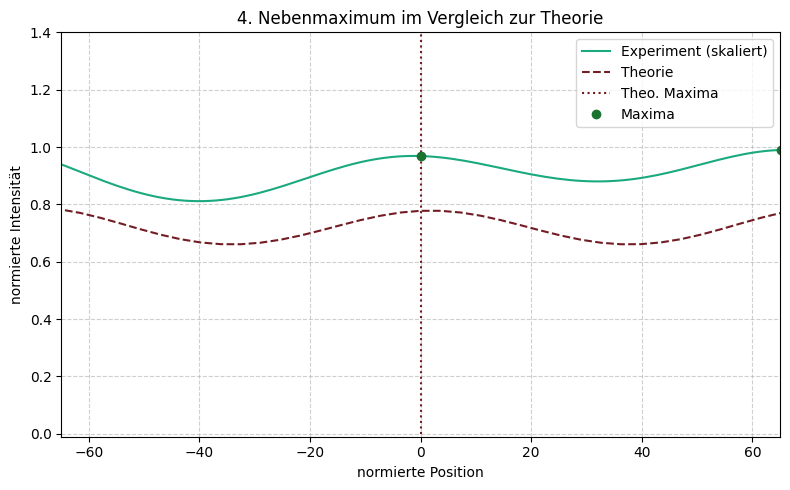

In [595]:
#Theorie
Y_theo_3, int_theo_3 = synthese_einzelspalt(pix_breit_1S, 5)

#Zentrieren
center_idx_3 = maxima_3[len(maxima_3)//2]

pix_pos_3_zentrisch = pix_pos_3 - pix_pos_3[center_idx_3]

# Theorie zentrieren
theo_center_idx_3 = theo_maxima_3[len(theo_maxima_3)//2]
Y_theo_3_zentrisch = Y_theo_3 - Y_theo_3[theo_center_idx_3]

# FWHM
fwhm_theo_3 = fwhm(Y_theo_3_zentrisch, int_theo_3)
fwhm_exp_3 = fwhm(pix_pos_3_zentrisch, int_3)

scale_3 = fwhm_theo_3 / fwhm_exp_3

pix_pos_3_scaled = pix_pos_3_zentrisch * scale_3
max_pix_exp_3_scaled = (pix_pos_3[maxima_3] - pix_pos_3[center_idx_3]) * scale_3

# theoretische Maxima-Positionen
theo_max_pos_3 = Y_theo_3_zentrisch[theo_maxima_3]

# --------------------------------------
# Plot
# --------------------------------------
plt.figure(figsize=(8,5))

# Experiment
plt.plot(
    pix_pos_3_scaled,
    int_3,
    label='Experiment (skaliert)',
    color=hellgruen
)

# Maxima markieren
plt.errorbar(
    x=max_pix_exp_3_scaled,
    y=int_3[maxima_3],
    fmt='o',
    color=gruen,
    label='Maxima'
)

# Theorie
plt.plot(
    Y_theo_3_zentrisch,
    int_theo_3,
    label='Theorie',
    color=weinrot,
    linestyle='--'
)

# Theoretische Maxima
plt.vlines(
    x=theo_max_pos_3,
    ymin=0,
    ymax=1.4,
    color=weinrot,
    linestyle=':',
    label='Theo. Maxima'
)

# Layout
plt.xlabel('normierte Position')
plt.ylabel('normierte Intensität')
plt.title('4. Nebenmaximum im Vergleich zur Theorie')
plt.legend()

plt.xlim((-65,65))
plt.ylim((-0.01,1.4))

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig(f'{safe_folder}3_Max_{aufgabe}.pdf')
plt.show()

## Alle Ordnungen zulassen

In [596]:
# --------------------------------------
#   Vergleich des experimentellen Hauptmaximums mit der theorie
# --------------------------------------
 
# Maxima finden
maxima_all = signal.find_peaks_cwt(int_all, 20, noise_perc = 20)
print(f'Maxima pxPos: {maxima_all}')

# Minima finden
minima_all = signal.find_peaks_cwt(-int_all[160:480], 10, noise_perc = 10) + 160
print(f'Minima pxPos: {minima_all}')

# Gleich ausrichten
pix_pos_all_zentrisch = pix_pos_all - maxima_all[1]

# Theoretisches Maxima finden
theo_maxima_all = signal.find_peaks(synthese_einzelspalt(pix_breit_1S,50)[1], height=0.5)[0]
print(f'theoretische Maxima pxPos: {theo_maxima_all}')

# Theoretische Minima finden
theo_minima_all = signal.find_peaks(-synthese_einzelspalt(pix_breit_1S,50)[1],height = -1)[0]
theo_minima_all = theo_minima_all # Nur mittlers elemente
print(f'theoretische Minima pxPos: {theo_minima_all}')

Maxima pxPos: [ 76 192 235 363 517]
Minima pxPos: [212 265 307 393]
theoretische Maxima pxPos: [ 51  53  55  57  59  61  63  65  67  69  71  73  75  77  79  81  83  85
  87  89  91  93  95  97  99 102 104 106 108 110 112 114 116 118 120 122
 124 126 128 130 132 134 136 138 140 142 144 146 148]
theoretische Minima pxPos: [ 52  54  56  58  60  62  64  66  68  70  72  74  76  78  80  82  84  86
  88  90  92  94  96  98 101 103 105 107 109 111 113 115 117 119 121 123
 125 127 129 131 133 135 137 139 141 143 145 147]


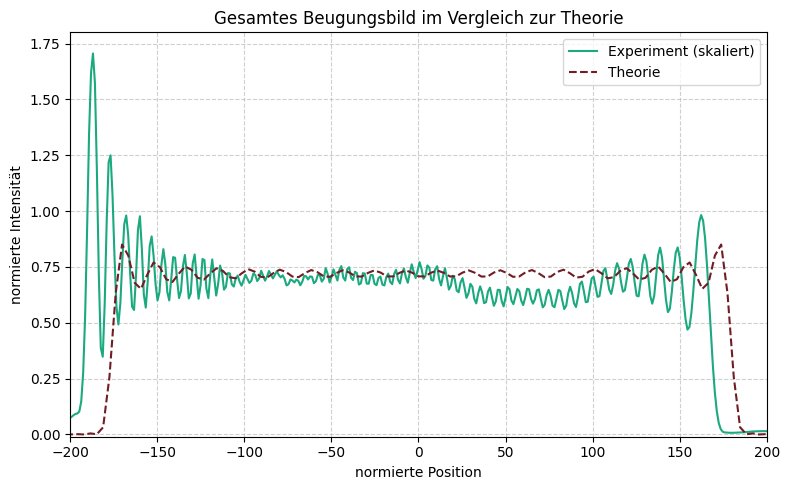

In [597]:
# Theorie
Y_theo_all, int_theo_all = synthese_einzelspalt(pix_breit_1S, 20)

# Zentrieren
center_idx_all = maxima_all[len(maxima_all)//2]
pix_pos_all_zentrisch = pix_pos_all - pix_pos_all[center_idx_all]

# Theorie zentrieren
theo_center_idx_all = theo_maxima_all[len(theo_maxima_all)//2]
Y_theo_all_zentrisch = Y_theo_all - Y_theo_all[theo_center_idx_all]

# FWHM
fwhm_theo_all = fwhm(Y_theo_all_zentrisch, int_theo_all)
fwhm_exp_all = fwhm(pix_pos_all_zentrisch, int_all)

scale_all = fwhm_theo_all / fwhm_exp_all

pix_pos_all_scaled = pix_pos_all_zentrisch * scale_all
max_pix_exp_all_scaled = (pix_pos_all[maxima_all] - pix_pos_all[center_idx_all]) * scale_all

# theoretische Maxima
theo_max_pos_all = Y_theo_all_zentrisch[theo_maxima_all]

# --------------------------------------
# Plot
# --------------------------------------
plt.figure(figsize=(8,5))

# Experiment
plt.plot(
    pix_pos_all_scaled + 4,
    int_all,
    label='Experiment (skaliert)',
    color=hellgruen
)

# # Maxima markieren
# plt.errorbar(
#     x=max_pix_exp_all_scaled,
#     y=int_all[maxima_all],
#     fmt='o',
#     color=gruen,
#     label='Maxima'
# )

# Theorie
plt.plot(
    Y_theo_all_zentrisch,
    int_theo_all,
    label='Theorie',
    color=weinrot,
    linestyle='--'
)

# # Theoretische Maxima
# plt.vlines(
#     x=theo_max_pos_all,
#     ymin=0,
#     ymax=1.2,
#     color=weinrot,
#     linestyle=':',
#     label='Theo. Maxima'
# )

# Layout
plt.xlabel('normierte Position')
plt.ylabel('normierte Intensität')
plt.title('Gesamtes Beugungsbild im Vergleich zur Theorie')
plt.legend()

plt.xlim((-200,200))
plt.ylim((-0.01,1.8))

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig(f'{safe_folder}all_Max_{aufgabe}.pdf')
plt.show()

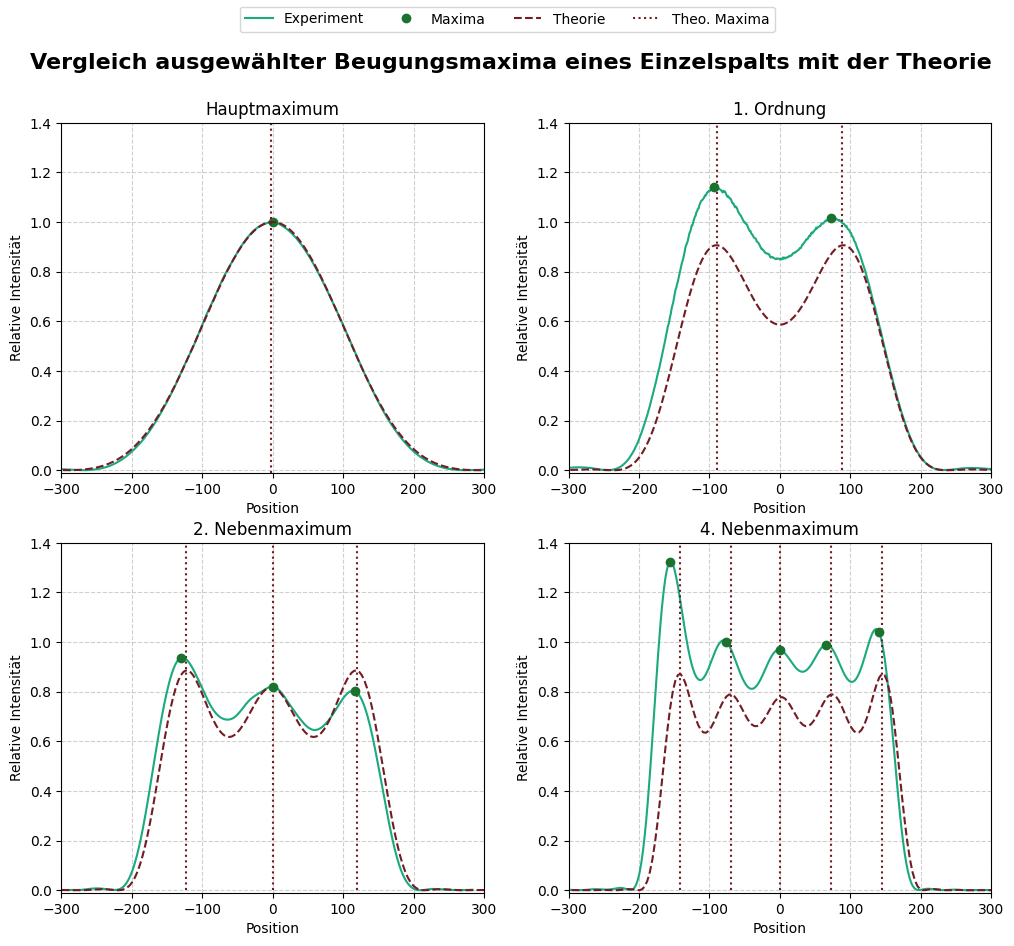

In [598]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))

xlim = (-300, 300)
ylim = (-0.01, 1.4)

# --------------------------------------
# Hauptmaximum
# --------------------------------------
axs[0,0].plot(pix_pos_0_scaled, int_0, color=hellgruen)
axs[0,0].plot(0, 1, 'o', color=gruen)
axs[0,0].plot(Y_theo_0, int_theo_0, '--', color=weinrot)
axs[0,0].axvline(theo_max_pos_0, color=weinrot, linestyle=':')
axs[0,0].set_title('Hauptmaximum')

# --------------------------------------
# 1. Ordnung
# --------------------------------------
axs[0,1].plot(pix_pos_1_scaled, int_1, color=hellgruen)
axs[0,1].errorbar(max_pix_exp_1_scaled, int_1[max_idx_1], fmt='o', color=gruen)
axs[0,1].plot(Y_theo_1, int_theo_1, '--', color=weinrot)
axs[0,1].vlines(theo_max_pos_1, 0, 1.4, color=weinrot, linestyles=':')
axs[0,1].set_title('1. Ordnung')

# --------------------------------------
# 2. Messung
# --------------------------------------
axs[1,0].plot(pix_pos_2_scaled, int_2, color=hellgruen)
axs[1,0].errorbar(max_pix_exp_2_scaled, int_2[maxima_2], fmt='o', color=gruen)
axs[1,0].plot(Y_theo_2_zentrisch, int_theo_2, '--', color=weinrot)
axs[1,0].vlines(theo_max_pos_2, 0, 1.4, color=weinrot, linestyles=':')
axs[1,0].set_title('2. Nebenmaximum')

# --------------------------------------
# 4. Nebenmaximum
# --------------------------------------
axs[1,1].plot(pix_pos_3_scaled, int_3, color=hellgruen)
axs[1,1].errorbar(max_pix_exp_3_scaled, int_3[maxima_3], fmt='o', color=gruen)
axs[1,1].plot(Y_theo_3_zentrisch, int_theo_3, '--', color=weinrot)
axs[1,1].vlines(theo_max_pos_3, 0, 1.4, color=weinrot, linestyles=':')
axs[1,1].set_title('4. Nebenmaximum')

# --------------------------------------
# Layout
# --------------------------------------
for ax in axs.flat:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xlabel('Position')
    ax.set_ylabel('Relative Intensität')

fig.suptitle(
    'Vergleich ausgewählter Beugungsmaxima eines Einzelspalts mit der Theorie',
    fontsize=16,
    fontweight='bold',
    y=0.95
)

handles = [
    plt.Line2D([0],[0], color=hellgruen),
    plt.Line2D([0],[0], marker='o', color=gruen, linestyle='None'),
    plt.Line2D([0],[0], linestyle='--', color=weinrot),
    plt.Line2D([0],[0], linestyle=':', color=weinrot)
]

labels = ['Experiment', 'Maxima', 'Theorie', 'Theo. Maxima']

fig.legend(handles, labels, loc='upper center', ncol=4)

# # plt.tight_layout(rect=[0,0,1,0.93])
# # plt.savefig(f'{safe_folder}vergleich_maxima_{aufgabe}.pdf')
# # plt.show()

# # plt.figure(figsize=(12,5))

# # plt.plot(pix_pos_all_scaled, int_all, color=hellgruen, label='Experiment')
# # plt.plot(Y_theo_all_zentrisch, int_theo_all, '--', color=weinrot, label='Theorie')

# # plt.xlabel('normierte Position')
# # plt.ylabel('normierte Intensität')
# # plt.title('Gesamtes Beugungsbild des Einzelspalts im Vergleich zur Theorie')

# # plt.xlim((-65,65))
# # plt.ylim((-0.01,1.4))

# # plt.grid(True, linestyle="--", alpha=0.6)
# # plt.legend()

# # plt.tight_layout()
# # plt.savefig(f'{safe_folder}gesamt_{aufgabe}.pdf')
# # plt.show()

In [599]:
def analyse_extrema(x, y, name="", distance=20, prominence=0.02):
    """
    Findet und gibt Maxima und Minima einer Intensitätskurve aus.
    """
    # Maxima
    max_peaks, max_props = find_peaks(y, distance=distance, prominence=prominence)

    print("\nMAXIMA:")
    print("-"*70)

    if len(max_peaks) == 0:
        print("Keine Maxima gefunden.")
    else:
        for i, p in enumerate(max_peaks):
            print(f"Maximum {i+1}:")
            print(f"  x-Position   = {x[p]:.3f}")
            print(f"  Intensität   = {y[p]:.4f}")
            print("-"*40)

    print(f"Anzahl Maxima: {len(max_peaks)}")


    # Minima
    min_peaks, min_props = find_peaks(-y, distance=distance, prominence=prominence)

    print("\n" + "="*70)
    print(f"Extrema-Auswertung: {name}")
    print("="*70)

    print("\nMINIMA:")
    print("-"*70)

    if len(min_peaks) == 0:
        print("Keine Minima gefunden.")
    else:
        for i, p in enumerate(min_peaks):
            print(f"Minimum {i+1}:")
            print(f"  x-Position   = {x[p]:.3f}")
            print(f"  Intensität   = {y[p]:.4f}")
            print("-"*40)

    print(f"Anzahl Minima: {len(min_peaks)}")

    # optional Rückgabe
    return max_peaks, min_peaks


# --------------------------------------
# Anwendung auf deine Datensätze
# --------------------------------------
max_0, min_0 = analyse_extrema(pix_pos_0_scaled, int_0, "Hauptmaximum")
max_1, min_1 = analyse_extrema(pix_pos_1_scaled, int_1, "1. Ordnung")
max_2, min_2 = analyse_extrema(pix_pos_2_scaled, int_2, "2. Nebenmaximum")
max_3, min_3 = analyse_extrema(pix_pos_3_scaled, int_3, "4. Nebenmaximum")




MAXIMA:
----------------------------------------------------------------------
Maximum 1:
  x-Position   = -0.958
  Intensität   = 1.0000
----------------------------------------
Anzahl Maxima: 1

Extrema-Auswertung: Hauptmaximum

MINIMA:
----------------------------------------------------------------------
Keine Minima gefunden.
Anzahl Minima: 0

MAXIMA:
----------------------------------------------------------------------
Maximum 1:
  x-Position   = -93.331
  Intensität   = 1.1422
----------------------------------------
Maximum 2:
  x-Position   = 72.469
  Intensität   = 1.0160
----------------------------------------
Anzahl Maxima: 2

Extrema-Auswertung: 1. Ordnung

MINIMA:
----------------------------------------------------------------------
Minimum 1:
  x-Position   = 0.000
  Intensität   = 0.8487
----------------------------------------
Anzahl Minima: 1

MAXIMA:
----------------------------------------------------------------------
Maximum 1:
  x-Position   = -128.375
  Inte

In [603]:
def analyse_extrema_theo(x, y, name="", distance=20, prominence=0.02):
    """
    Findet Maxima und Minima in theoretischen Intensitätskurven.
    """

    # Maxima
    max_peaks, _ = find_peaks(y, distance=distance, prominence=prominence)

    print("\nTHEORETISCHE MAXIMA:")
    print("-"*70)

    if len(max_peaks) == 0:
        print("Keine Maxima gefunden.")
    else:
        for i, p in enumerate(max_peaks):
            print(f"Maximum {i+1}:")
            print(f"  x-Position   = {x[p]:.5f}")
            print(f"  Intensität   = {y[p]:.5f}")
            print("-"*40)

    print(f"Anzahl Maxima: {len(max_peaks)}")

    # Minima
    min_peaks, _ = find_peaks(-y, distance=distance, prominence=prominence)

    print("\n" + "="*70)
    print(f"Theorie-Extrema-Auswertung: {name}")
    print("="*70)

    print("\nTHEORETISCHE MINIMA:")
    print("-"*70)

    if len(min_peaks) == 0:
        print("Keine Minima gefunden.")
    else:
        for i, p in enumerate(min_peaks):
            print(f"Minimum {i+1}:")
            print(f"  x-Position   = {x[p]:.5f}")
            print(f"  Intensität   = {y[p]:.5f}")
            print("-"*40)

    print(f"Anzahl Minima: {len(min_peaks)}")

    return max_peaks, min_peaks

max_th_0, min_th_0 = analyse_extrema_theo(Y_theo_0, int_theo_0, "Hauptmaximum (Theorie)")
max_th_1, min_th_1 = analyse_extrema_theo(Y_theo_1, int_theo_1, "1. Ordnung (Theorie)")
max_th_2, min_th_2 = analyse_extrema_theo(Y_theo_2_zentrisch, int_theo_2, "2. Nebenmaximum (Theorie)")
max_th_3, min_th_3 = analyse_extrema_theo(Y_theo_3_zentrisch, int_theo_3, "4. Nebenmaximum (Theorie)")


THEORETISCHE MAXIMA:
----------------------------------------------------------------------
Maximum 1:
  x-Position   = -1.81005
  Intensität   = 0.99982
----------------------------------------
Anzahl Maxima: 1

Theorie-Extrema-Auswertung: Hauptmaximum (Theorie)

THEORETISCHE MINIMA:
----------------------------------------------------------------------
Keine Minima gefunden.
Anzahl Minima: 0

THEORETISCHE MAXIMA:
----------------------------------------------------------------------
Maximum 1:
  x-Position   = -88.69246
  Intensität   = 0.90637
----------------------------------------
Maximum 2:
  x-Position   = 88.69246
  Intensität   = 0.90637
----------------------------------------
Anzahl Maxima: 2

Theorie-Extrema-Auswertung: 1. Ordnung (Theorie)

THEORETISCHE MINIMA:
----------------------------------------------------------------------
Minimum 1:
  x-Position   = -1.81005
  Intensität   = 0.58666
----------------------------------------
Anzahl Minima: 1

THEORETISCHE MAXIMA:


In [ ]:
def percent_dev(exp, theo):
    return np.abs((abs(exp) - abs(theo)) / theo) * 100

exp_data = [
    (pix_pos_0_scaled, int_0, max_0, min_0, "Hauptmaximum"),
    (pix_pos_1_scaled, int_1, max_1, min_1, "1. Ordnung"),
    (pix_pos_2_scaled, int_2, max_2, min_2, "2. Ordnung"),
    (pix_pos_3_scaled, int_3, max_3, min_3, "4. Ordnung"),
]

theo_data = [
    (Y_theo_0, int_theo_0, max_th_0, min_th_0),
    (Y_theo_1, int_theo_1, max_th_1, min_th_1),
    (Y_theo_2_zentrisch, int_theo_2, max_th_2, min_th_2),
    (Y_theo_3_zentrisch, int_theo_3, max_th_3, min_th_3),
]

all_dfs = []

for i in range(len(exp_data)):

    x_exp, y_exp, max_exp, min_exp, name = exp_data[i]
    x_th, y_th, max_th, min_th = theo_data[i]

    rows = []

    def add_rows(kind, exp_idx, th_idx):

        n = min(len(exp_idx), len(th_idx))

        for j in range(n):
            e = exp_idx[j]
            t = th_idx[j]

            rows.append({
                "Ordnung": name,
                "Typ": f'{j + 1}. {kind}',
                # "Index": j + 1,

                r"\text{theo } x_\text{pos}": x_th[t],
                r"\text{exp } x_\text{pos}": x_exp[e],
                r"\Delta x [\%]": percent_dev(x_exp[e], x_th[t]),

                r"\text{theo } I_\text{rel}": y_th[t],
                r"\text{exp } I_\text{rel}": f'{y_exp[e]:.2f} \\pm 0.03',
                r"\Delta I [\%]": percent_dev(y_exp[e], y_th[t]),
                r"\text{Std.Abw. } \sigma": sigma_abweichung(y_th, y_exp, 0.03)
            })

    # add_rows("Max", max_exp, max_th)
    # add_rows("Min", min_exp, min_th)

    df = pd.DataFrame(rows)
    all_dfs.append(df)

print()

df_all = pd.concat(all_dfs, ignore_index=True)


latex_all = df_all.to_latex(
    index=False,
    float_format="%.2f",
    column_format = 'l l | C C | C || C C | C | C',
    caption="Vergleich theoretischer und experimenteller Extrema aller Ordnungen",
    label="tab:extrema_all",
)

print(latex_all)

ValueError: operands could not be broadcast together with shapes (200,) (728,) 

# Der Doppelspalt

In [ ]:
# --------------------------------------
#   Experimentdaten für die Spaltbreite
# --------------------------------------

# Brennweite der Linse von mm in m
f1 = 80e-3

# Bildweite b von cm in m
b_weit = 35.0e-2
err_b_weit = 0.5e-2

# Objektabstand zur Linse L1 von mm in m
obj_abst = 115e-3
err_obj_abst = 0.5e-3

# Spaltbreite des Analysespaltes von mm in m
anaSpalt_breit = np.array([0.057, 0.171]) * 1e-3
err_anaSpalt_breit = 0.5e-6

# Kamera Pixelauflösung nach Praktikumsskipt umgerechnet in m/px
px_breit = 3.45e-6

# Fehlender Wert der Spaltbreite Doppelspalt in px 
# Wert wurde vom Kommilitonen übernommen
pix_breit_dop = 251
err_pix_breit_dop = 4

# Fehlender Wert des Spaltabstandes in px 
# Wert wurde vom Kommilitonen übernommen
pix_abst_dop = 586
err_pix_abst_dop = 5

In [ ]:
aufgabe = '3a'
folder = "./A3/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Einlesen der Textdateien
# --------------------------------------

# Daten für das 0. Hauptmaximum
pix_pos_dop, int_dop = np.loadtxt(f'{folder}Doppelspalt-Hauptmaximum_Plain-Ohne-Alles', unpack=True)


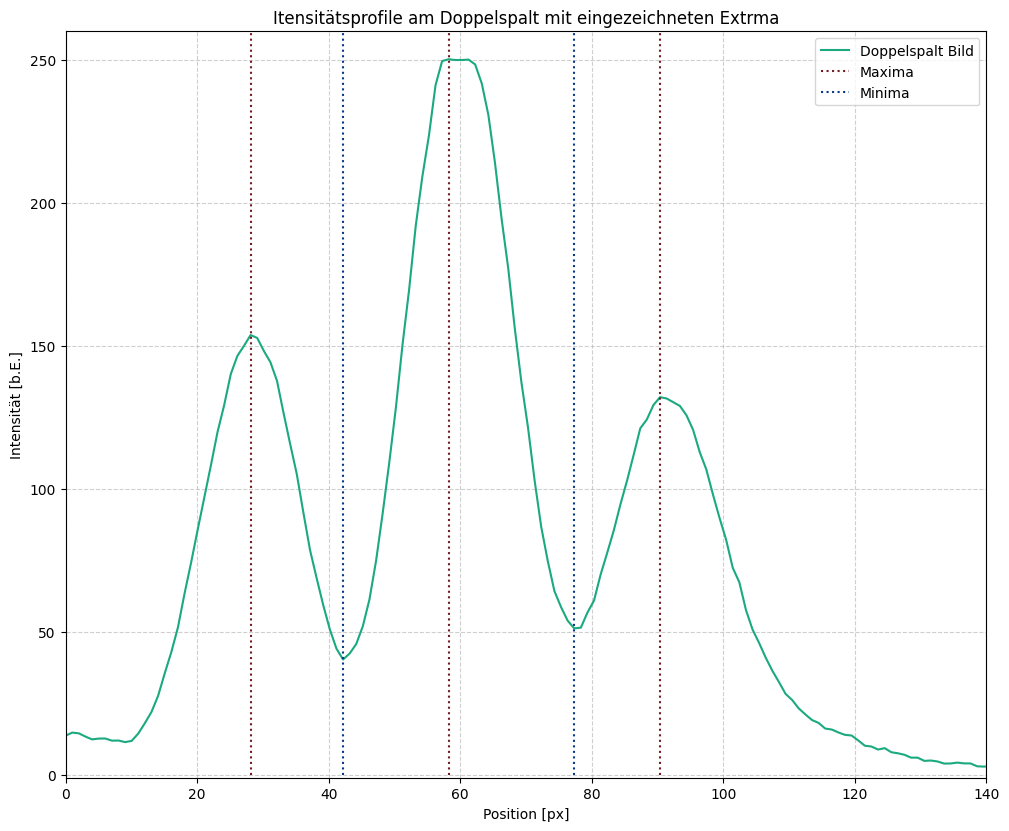

In [ ]:
aufgabe = '3a'
folder = "./A3/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Plot Doppelspalt
# --------------------------------------

# Maxima finden
peaks, _ = find_peaks(int_dop - min(int_dop), distance=30, prominence=5)

# Minima finden (invertiertes Signal)
valleys, _ = find_peaks(-(int_dop - min(int_dop)), distance=30, prominence=5)

fig, axes = plt.subplots(1, figsize=(10, 8))

# Regression
plt.plot(
    pix_pos_dop, 
    int_dop - min(int_dop),
    label = "Doppelspalt Bild",
    color = hellgruen
    )

# Extrema
plt.vlines(
    pix_pos_dop[peaks],
    0,
    # (int_dopp - min(int_dopp))[peaks],
    260,
    linestyle=':',
    color=weinrot,
    label='Maxima'
)

plt.vlines(
    pix_pos_dop[valleys],
    0,
    # (int_dopp - min(int_dopp))[valleys],
    260,
    linestyle=':',
    color=blau,
    label='Minima'
)

plt.legend()
plt.ylim(-1, 260)
plt.xlim(0, 140)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.xlabel('Position [px]')
plt.ylabel('Intensität [b.E.]')
plt.title('Itensitätsprofile am Doppelspalt mit eingezeichneten Extrma')
plt.savefig(f"{safe_folder}Dop_sig{aufgabe}.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# --------------------------------------
#   Calc Doppelspalt-Breite (M1: nutzung der Bildweite)
# --------------------------------------

b_sym, B_sym, f_sym, mu_sym = sp.symbols(r'b, {B_\text{d}}, {f_1}, \mu')
params = [b_sym , B_sym, f_sym, mu_sym]

G_func = f_sym * B_sym * mu_sym / (b_sym - f_sym)

values = np.array([
    b_weit, err_b_weit,
    pix_breit_dop, err_pix_breit_dop, # Die Werte stimmen so nicht... Es wurde Beispielwert eingetragen
    f1,
    px_breit
])

breit_b = calc2(G_func, params, values, [f_sym, mu_sym], p_latex=False)
breit_b_val = breit_b[0][0]
breit_b_err = breit_b[0][1]

# --------------------------------------
#   Calc Doppelspalt-Breite (M2: nutzung der Gegenstandweite)
# --------------------------------------
g_sym , B_sym, f_sym, mu_sym = sp.symbols(r'g, {B_\text{d}}, {f_1}, \mu')
params = [g_sym , B_sym, f_sym, mu_sym]

G_func = B_sym * mu_sym / f_sym * (g_sym - f_sym)

values = np.array([
    obj_abst, err_obj_abst,
    pix_breit_dop, err_pix_breit_dop, # Die Werte stimmen so nicht... Es wurde Beispielwert eingetragen
    f1,
    px_breit
])

breit_g = calc2(G_func, params, values, [f_sym, mu_sym], p_latex=False)
breit_g_val = breit_g[0][0]
breit_g_err = breit_g[0][1]


sigma_abweichung(G_b[0][0], G_g[0][0], G_b[0][1], G_g[0][1])

Results:
[[2.56577778e-04 6.26858816e-06]]
Results:
[[3.78853125e-04 8.10821681e-06]]


np.float64(15.006687535137283)

In [ ]:
# --------------------------------------
#   Calc Spaltabstand (M1: nutzung der Bildweite)
# --------------------------------------

b_sym, B_sym, f_sym, mu_sym = sp.symbols(r'b, {B_\text{d}}, {f_1}, \mu')
params = [b_sym , B_sym, f_sym, mu_sym]

G_func = f_sym * B_sym * mu_sym / (b_sym - f_sym)

values = np.array([
    b_weit, err_b_weit,
    pix_abst_dop, err_pix_abst_dop, # Die Werte stimmen so nicht... Es wurde Beispielwert eingetragen
    f1,
    px_breit
])

abst_b = calc2(G_func, params, values, [f_sym, mu_sym], p_latex=False)
abst_b_val = abst_b[0][0]
abst_b_err = abst_b[0][1]


# --------------------------------------
#   Calc Spaltabstand (M2: nutzung der Gegenstandweite)
# --------------------------------------
g_sym , B_sym, f_sym, mu_sym = sp.symbols(r'g, {B_\text{d}}, {f_1}, \mu')
params = [g_sym , B_sym, f_sym, mu_sym]

G_func = B_sym * mu_sym / f_sym * (g_sym - f_sym)

values = np.array([
    obj_abst, err_obj_abst,
    pix_abst_dop, err_pix_abst_dop, # Die Werte stimmen so nicht... Es wurde Beispielwert eingetragen
    f1,
    px_breit
])

abst_g = calc2(G_func, params, values, [f_sym, mu_sym], p_latex=False)
abst_g_val = abst_g[0][0]
abst_g_err = abst_g[0][1]


sigma_abweichung(G_b[0][0], G_g[0][0], G_b[0][1], G_g[0][1])

Results:
[[5.99022222e-04 1.22138527e-05]]
Results:
[[8.84493750e-04 1.47178239e-05]]


np.float64(15.006687535137283)

In [ ]:
quot_b = abst_b_val/breit_b_val

def beugung_doppelspalt(x):
    return np.sinc(x)**2*np.cos(np.pi*quot_b*x)**2

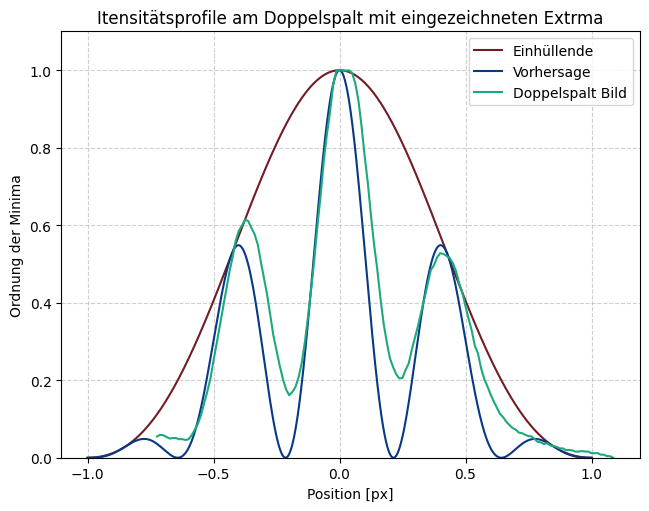

In [ ]:
# --------------------------------------
#   Inensitäten am Doppelspalt mit FWHM
# --------------------------------------
# Index des höchsten Peaks (0. Hauptmaximum)
main_peak_idx = peaks[np.argmax(int_dop[peaks])]

# Zugehörige x-Position
x0 = pix_pos_dop[main_peak_idx]

# Zentrierte x-Achse
pix_pos_centered = pix_pos_dop - x0

int_dop_shifted = int_dop - np.min(int_dop)   # auf 0 setzen
int_dop_norm = int_dop_shifted / np.max(int_dop_shifted)  # auf 1 skalieren

# FWHM
fwhm_data = fwhm(pix_pos_centered, int_dop_norm)
fwhm_theory = fwhm(x, beugung_doppelspalt(x))
scale = fwhm_theory / fwhm_data

pix_pos_scaled = pix_pos_centered * scale

aufgabe = '3a'
folder = "./A3/"
safe_folder = "../img/plots/"

quot_b = abst_b_val/breit_b_val

def beugung_doppelspalt(x):
    return np.sinc(x)**2*np.cos(np.pi*quot_b*x)**2

a = 0
x=np.linspace(-(a+1),a+1,2000)

plt.plot(
    x,
    beugung_spalt(x),
    label='Einhüllende',
    color = weinrot
    )


plt.plot(
    x,
    beugung_doppelspalt(x),
    label='Vorhersage',
    color = blau
    )

# Muss von der Intensität und Breite angepasst werden
plt.plot(
    pix_pos_scaled, 
    int_dop_norm,
    label="Doppelspalt Bild",
    color=hellgruen
    )


plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.xlabel('Position [px]')
plt.ylabel('Ordnung der Minima')
plt.title('Itensitätsprofile am Doppelspalt mit eingezeichneten Extrma')
plt.savefig(f"{safe_folder}Dop_sig_ex_theo_vgl{aufgabe}.pdf", dpi=300, bbox_inches='tight')
plt.show()

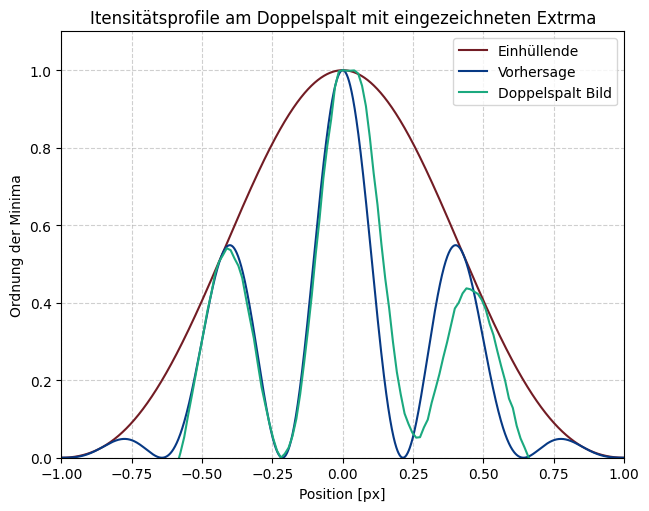

In [ ]:
aufgabe = '3b'
folder = "./A3/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Inensitäten am Doppelspalt mit FWHM und anpassen der Minima
# --------------------------------------
# Index des höchsten Peaks (0. Hauptmaximum)
main_peak_idx = peaks[np.argmax(int_dop[peaks])]

# Zugehörige x-Position
x0 = pix_pos_dop[main_peak_idx]

# Zentrierte x-Achse
pix_pos_centered = (pix_pos_dop - x0)


int_dop_shifted = int_dop - int_dop[valleys[0]]
int_dop_norm = int_dop_shifted / np.max(int_dop_shifted)

err_int_dop_norm = 3 / np.max(int_dop_shifted)

# FWHM
fwhm_data = fwhm(pix_pos_centered, int_dop_norm)
fwhm_theory = fwhm(x, beugung_doppelspalt(x))
scale = fwhm_theory / fwhm_data /1.5

pix_pos_scaled = pix_pos_centered * scale

aufgabe = '3a'
folder = "./A3/"
safe_folder = "../img/plots/"

quot_b = abst_b_val/breit_b_val

def beugung_doppelspalt(x):
    return np.sinc(x)**2*np.cos(np.pi*quot_b*x)**2

a = 0
x=np.linspace(-(a+1),a+1,2000)

plt.plot(
    x,
    beugung_spalt(x),
    label='Einhüllende',
    color = weinrot
    )


plt.plot(
    x,
    beugung_doppelspalt(x),
    label='Vorhersage',
    color = blau
    )

# Muss von der Intensität und Breite angepasst werden
plt.plot(
    pix_pos_scaled, 
    int_dop_norm,
    label="Doppelspalt Bild",
    color=hellgruen
    )


plt.legend()
plt.xlim(-1, 1)
plt.ylim(0, 1.1)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.xlabel('Position [px]')
plt.ylabel('Ordnung der Minima')
plt.title('Itensitätsprofile am Doppelspalt mit eingezeichneten Extrma')
plt.savefig(f"{safe_folder}Dop_sig_ex_theo_vgl{aufgabe}.pdf", dpi=300, bbox_inches='tight')
plt.show()

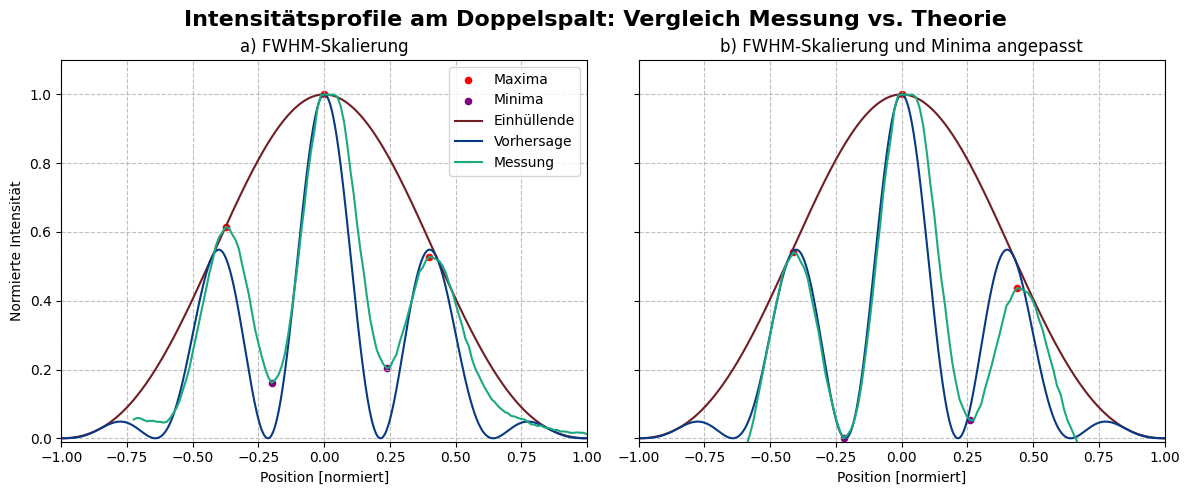

In [ ]:
# --------------------------------------
#   Finaler ploti für doppelspalt
# --------------------------------------


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

main_peak_idx = peaks[np.argmax(int_dop[peaks])]
x0 = pix_pos_dop[main_peak_idx]
pix_centered = pix_pos_dop - x0

fwhm_theory = fwhm(x, beugung_doppelspalt(x))
# Plot 3a
int_norm_a = (int_dop - np.min(int_dop))
int_norm_a /= np.max(int_norm_a)

scale_a = fwhm_theory / fwhm(pix_centered, int_norm_a)
pix_scaled_a = pix_centered * scale_a

ax = axes[0]
ax.scatter(pix_scaled_a[peaks], int_norm_a[peaks], color='red', s=20, label='Maxima')
ax.scatter(pix_scaled_a[valleys], int_norm_a[valleys], color='purple', s=20, label='Minima')

ax.plot(x, beugung_spalt(x), label='Einhüllende', color=weinrot)
ax.plot(x, beugung_doppelspalt(x), label='Vorhersage', color=blau)
ax.plot(pix_scaled_a, int_norm_a, label="Messung", color=hellgruen)

ax.set(title="a) FWHM-Skalierung", xlim=(-1, 1), ylim=(-0.01, 1.1), xlabel='Position [normiert]')
ax.grid(True, linestyle="--", alpha=0.8)
ax.legend()


# Plot 3b
int_norm_b = (int_dop - int_dop[valleys[0]])
int_norm_b /= np.max(int_norm_b)

scale_b = fwhm_theory / fwhm(pix_centered, int_norm_b) / 1.5
pix_scaled_b = pix_centered * scale_b

ax = axes[1]
ax.scatter(pix_scaled_b[peaks], int_norm_b[peaks], color='red', s=20, label='Maxima')
ax.scatter(pix_scaled_b[valleys], int_norm_b[valleys], color='purple', s=20, label='Minima')

ax.plot(x, beugung_spalt(x), label='Einhüllende', color=weinrot)
ax.plot(x, beugung_doppelspalt(x), label='Vorhersage', color=blau)
ax.plot(pix_scaled_b, int_norm_b, label="Messung", color=hellgruen)

ax.set(title="b) FWHM-Skalierung und Minima angepasst", xlim=(-1, 1), ylim=(-0.01, 1.1), xlabel='Position [normiert]')
ax.grid(True, linestyle="--", alpha=0.8)
# ax.legend()


# Layout
axes[0].set_ylabel('Normierte Intensität')
fig.suptitle("Intensitätsprofile am Doppelspalt: Vergleich Messung vs. Theorie", fontsize=16, weight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{safe_folder}Dop_sig_ex_theo_vgl_combined.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# theoretische Extrema bestimmen
y_theo = beugung_doppelspalt(x)

peaks_theo, _ = find_peaks(y_theo)
valleys_theo, _ = find_peaks(-y_theo)

# sortieren nach Position
extrema_theo_idx = sorted(
    list(peaks_theo) + list(valleys_theo),
    key=lambda i: x[i]
)

center_idx = np.argmax(y_theo)
extrema_theo_idx = sorted(extrema_theo_idx, key=lambda i: abs(i-center_idx))[:5]
extrema_theo_idx = sorted(extrema_theo_idx, key=lambda i: x[i])

I_theo = y_theo[extrema_theo_idx]

In [ ]:

def extract_extrema(pix_scaled, int_norm, peaks, valleys):
    idx_all = sorted(
        list(peaks) + list(valleys),
        key=lambda i: pix_scaled[i]
    )
    
    # 5 zentrale Extrema auswählen
    center_idx = np.argmin(np.abs(pix_scaled))
    idx_all = sorted(idx_all, key=lambda i: abs(i-center_idx))[:5]
    idx_all = sorted(idx_all, key=lambda i: pix_scaled[i])
    
    return int_norm[idx_all]


I_exp1 = extract_extrema(pix_scaled_a, int_norm_a, peaks, valleys)
I_exp2 = extract_extrema(pix_scaled_b, int_norm_b, peaks, valleys)

In [ ]:
int_dop_shifted = int_dop - int_dop[valleys[0]]
int_dop_norm = int_dop_shifted / np.max(int_dop_shifted)

err_int_dop_norm = 3 / np.max(int_dop_shifted)




In [ ]:
def select_central_extrema(x, y, peaks, valleys, n=3):
    idx_all = np.array(sorted(
        list(peaks) + list(valleys),
        key=lambda i: x[i]
    ))

    center_idx = np.argmax(y)
    
    idx_sorted = sorted(idx_all, key=lambda i: abs(i - center_idx))
    idx_selected = sorted(idx_sorted[:n], key=lambda i: x[i])
    
    return np.array(idx_selected)

peaks, _ = find_peaks(int_dop_norm)
valleys, _ = find_peaks(-int_dop_norm)

idx_exp = select_central_extrema(
    pix_pos_centered,
    int_dop_norm,
    peaks,
    valleys,
    n=3
)

I_exp = int_dop_norm[idx_exp]
x_exp = pix_pos_centered[idx_exp]

err_I_exp = np.full_like(I_exp, 10 / np.max(int_dop_shifted))
err_x_exp = np.full_like(x_exp, 3)

print(I_exp)


[1.         0.99874818 0.9994403 ]


In [ ]:
# --------------------------------------
#  LatexExport
# --------------------------------------

extrema_labels = ['-1 Max', '-1 Min', '0 Max', '1 Min', '1 Max']

str_exp_1 = []
str_ab_1 = []

str_exp_2 = []
str_ab_2 = []

str_messp = []
str_ab_messp = []


for i in range (len(extrema_labels)):
    str_exp_1.append(f'{I_exp1[i]:.3f} \\pm {err_int_dop_norm:.2g}')
    str_ab_1.append(sigma_abweichung(I_exp1[i], I_theo[i], err_int_dop_norm))

    str_exp_2.append(f'{I_exp2[i]:.3f} \\pm {err_int_dop_norm:.2g}')
    str_ab_2.append(sigma_abweichung(I_exp2[i], I_theo[i], err_int_dop_norm))

    # str_messp.append(f'{I_exp[i]:.3f} \\pm {err_I_exp:.1f}')
    # str_ab_messp.append(sigma_abweichung(I_exp[i], I_theo[i], err_I_exp))


df = pd.DataFrame({
    'Extremum': extrema_labels,
    r'\text{theo } I_\text{rel}': I_theo,

    # r'\text{messp } I_\text{rel}': str_messp,
    # r'\text{Std.Abw } \sigma': str_ab_messp,

    r'\text{exp,1 } I_\text{rel}': str_exp_1,
    r'\text{Std.Abw } \sigma ': str_ab_1,
    
    r'\text{exp,2 } I_\text{rel}': str_exp_2,
    r'\text{Std.Abw } \sigma  ': str_ab_2,
})

latex_table = df.to_latex(
    index=False,
    escape=False,
    float_format="%.2f",
    column_format='l C || C | C || C | C || C | C',
    position='h!',
    caption=' '
)

print(latex_table)

\begin{table}[h!]
\caption{ }
\begin{tabular}{l C || C | C || C | C || C | C}
\toprule
Extremum & \text{theo } I_\text{rel} & \text{exp,1 } I_\text{rel} & \text{Std.Abw } \sigma  & \text{exp,2 } I_\text{rel} & \text{Std.Abw } \sigma   \\
\midrule
-1 Max & 0.55 & 0.615 \pm 0.014 & 4.63 & 0.541 \pm 0.014 & 0.55 \\
-1 Min & 0.00 & 0.161 \pm 0.014 & 11.28 & 0.000 \pm 0.014 & 0.00 \\
0 Max & 1.00 & 1.000 \pm 0.014 & 0.00 & 1.000 \pm 0.014 & 0.00 \\
1 Min & 0.00 & 0.205 \pm 0.014 & 14.32 & 0.052 \pm 0.014 & 3.63 \\
1 Max & 0.55 & 0.528 \pm 0.014 & 1.44 & 0.437 \pm 0.014 & 7.80 \\
\bottomrule
\end{tabular}
\end{table}



# Aufgabe 5) Doppelspalt Beugungsbild

In [ ]:
aufgabe = '5a'
folder = "./A5/"
safe_folder = "../img/plots/"

# --------------------------------------
#  Einlesen der Messdaten
# --------------------------------------

# Nur Hauptmaximum zugelassen
pix_pos_dop_0, int_dop_0 = np.loadtxt(f'{folder}0-Ordnung', unpack=True)

# 1 Nebenmaximum zugelassen
pix_pos_dop_1, int_dop_1 = np.loadtxt(f'{folder}1-Ordnung', unpack=True)

# 2 Nebenmaximum zugelassen
pix_pos_dop_2, int_dop_2 = np.loadtxt(f'{folder}3-Ordnung', unpack=True)

# Spaltbreiten des Analysespaltes. für 2 leider nicht dokumentiert. von mikrometer in m
breit_anaSpalt_0 = 57e-6
breit_anaSpalt_1 = 171e-6
err_anaSpalt = 5e-6

In [ ]:
# --------------------------------------
#  Extrema
# --------------------------------------

# Vereinfachen
def finde_extrema(x, y, prominence=10, distance=15):
    # Maxima
    peaks, props = find_peaks(y, prominence=prominence, distance=distance)

    # Minima = Peaks der invertierten Funktion
    troughs, props_min = find_peaks(-y, prominence=prominence, distance=distance)

    return peaks, troughs

peaks0, mins0 = finde_extrema(pix_pos_dop_0, int_dop_0)
peaks0, mins0 = finde_extrema(pix_pos_dop_0, int_dop_0)
peaks1, mins1 = finde_extrema(pix_pos_dop_1, int_dop_1)
peaks2, mins2 = finde_extrema(pix_pos_dop_2, int_dop_2)

# Positionen der Extrema
x_peaks0 = pix_pos_dop_0[peaks0]
y_peaks0 = int_dop_0[peaks0]

x_mins0 = pix_pos_dop_0[mins0]
y_mins0 = int_dop_0[mins0]

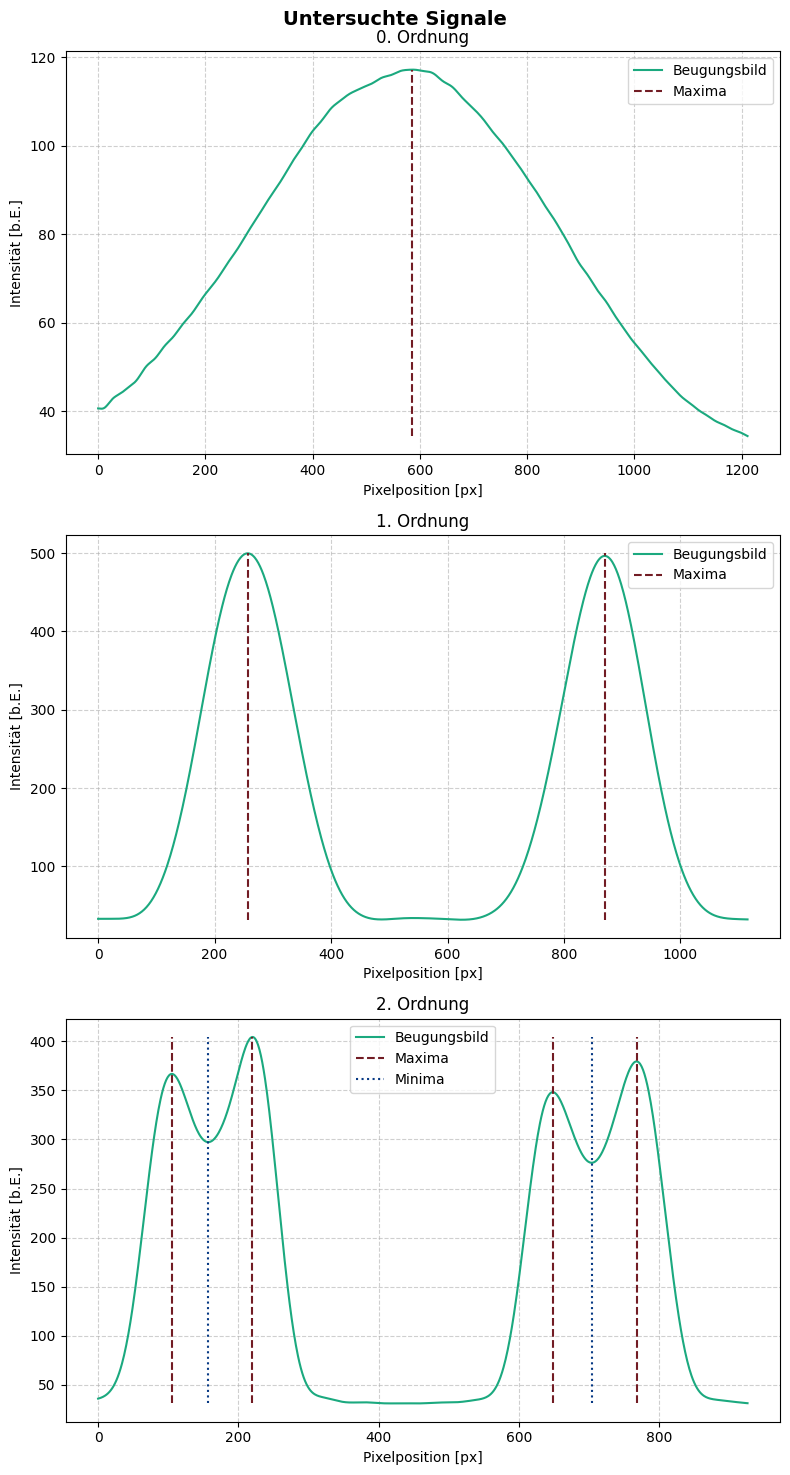

In [ ]:
aufgabe = '5a'
folder = "./A5/"
safe_folder = "../img/plots/"

# --------------------------------------
#  Plotting der Signale
# --------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharey=False)

# 0. Ordnung
x0 = pix_pos_dop_0 - min(pix_pos_dop_0)
y0 = int_dop_0

peaks0, mins0 = finde_extrema(x0, y0)

axes[0].plot(x0, y0, color=hellgruen, label="Beugungsbild")

axes[0].vlines(x0[peaks0], ymin=min(y0), ymax=max(y0),
               color=weinrot, linestyles="dashed", label="Maxima")

# axes[0].vlines(x0[mins0], ymin=min(y0), ymax=max(y0),
#                color=blau, linestyles="dotted", label="Minima")

axes[0].set_title("0. Ordnung")
axes[0].set_xlabel("Pixelposition [px]")
axes[0].set_ylabel("Intensität [b.E.]")
axes[0].grid(True, which="both", linestyle="--", alpha=0.6)
axes[0].legend()

# 1. Ordnung
x1 = pix_pos_dop_1
y1 = int_dop_1

peaks1, mins1 = finde_extrema(x1, y1)

axes[1].plot(x1, y1, color=hellgruen, label="Beugungsbild")

axes[1].vlines(x1[peaks1], ymin=min(y1), ymax=max(y1),
               color=weinrot, linestyles="dashed", label="Maxima")

# axes[1].vlines(x1[mins1], ymin=min(y1), ymax=max(y1),
#                color=blau, linestyles="dotted", label="Minima")

axes[1].set_title("1. Ordnung")
axes[1].set_xlabel("Pixelposition [px]")
axes[1].set_ylabel("Intensität [b.E.]")
axes[1].grid(True, which="both", linestyle="--", alpha=0.6)
axes[1].legend()


# 3. Ordnung
x2 = pix_pos_dop_2
y2 = int_dop_2

peaks2, mins2 = finde_extrema(x2, y2)

axes[2].plot(x2, y2, color=hellgruen, label="Beugungsbild")

axes[2].vlines(x2[peaks2], ymin=min(y2), ymax=max(y2),
               color=weinrot, linestyles="dashed", label="Maxima")

true_mins2 = np.array([mins2[0], mins2[2]])

axes[2].vlines(x2[true_mins2], ymin=min(y2), ymax=max(y2),
               color=blau, linestyles="dotted", label="Minima")

axes[2].set_title("2. Ordnung")
axes[2].set_xlabel("Pixelposition [px]")
axes[2].set_ylabel("Intensität [b.E.]")
axes[2].grid(True, which="both", linestyle="--", alpha=0.6)
axes[2].legend()


plt.suptitle("Untersuchte Signale", size=14, weight="bold")
plt.tight_layout()
plt.savefig(f"{safe_folder}Sig_Dop_{aufgabe}.pdf", dpi=300)
plt.show()

In [ ]:
#Theoretische Vorhersage für die Fouriersynthese
def synthese_doppelspalt(g, d, n):
    
    # y-Achse
    Y = np.linspace(-1, 1, 2000) * (g + 10)

    f_modifiziert = []

    for y in Y:

        # Integrand (y muss als Parameter übergeben werden!)
        def doppelspalt(k):
            return (d/np.pi *
                    np.cos(k*g/2) *
                    np.sin(k*d/2)/(k*d/2) *
                    np.cos(y*k))

        result, _ = quad(doppelspalt, 0, 2*np.pi*n/d)
        f_modifiziert.append(result**2)

    f_modifiziert = np.array(f_modifiziert)

    # Normierung
    f_modifiziert /= np.max(f_modifiziert)

    return Y, f_modifiziert

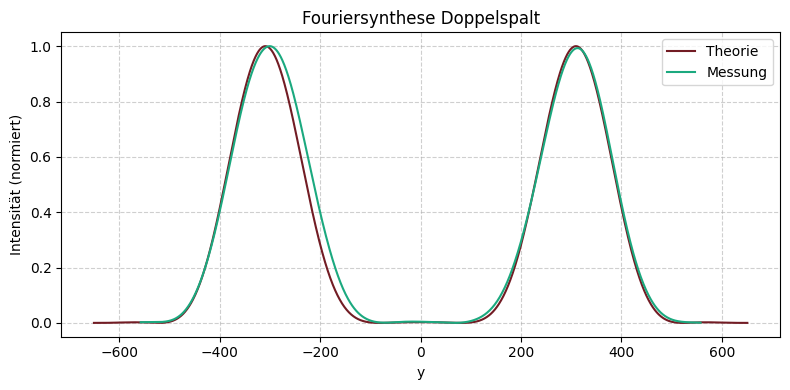

In [ ]:
aufgabe = '5b'
folder = "./A5/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Anpassen der Messwerte
# --------------------------------------

# AUf Nullhöhe setzen
int_dop_1_null = int_dop_1 - min(int_dop_1)

x_exp = pix_pos_dop_1 - np.mean(pix_pos_dop_1)
I_exp = int_dop_1_null / np.max(int_dop_1_null)

# --------------------------------------
#  Plotting
# --------------------------------------
# Paraeter 
g = abst_b_val/px_breit
d = breit_b_val/px_breit
n = 1

y_th, I_th = synthese_doppelspalt(g, d, n)

# FWHM
fwhm_exp = fwhm(x_exp, I_exp)
fwhm_th = fwhm(y_th, I_th)
scale = fwhm_exp / fwhm_th

y_th_scaled = y_th * scale

plt.figure(figsize=(8,4))

plt.plot(
    y_th_scaled,
    I_th,
    color=weinrot, 
    label="Theorie"
    )

plt.plot(
    x_exp, 
    I_exp, 
    label="Messung",
    color=hellgruen
    )
plt.title("Fouriersynthese Doppelspalt")
plt.xlabel("y")
plt.ylabel("Intensität (normiert)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(f'{safe_folder}Doppelspalt_1Ordnung_{aufgabe}.pdf', dpi=300)
plt.show()

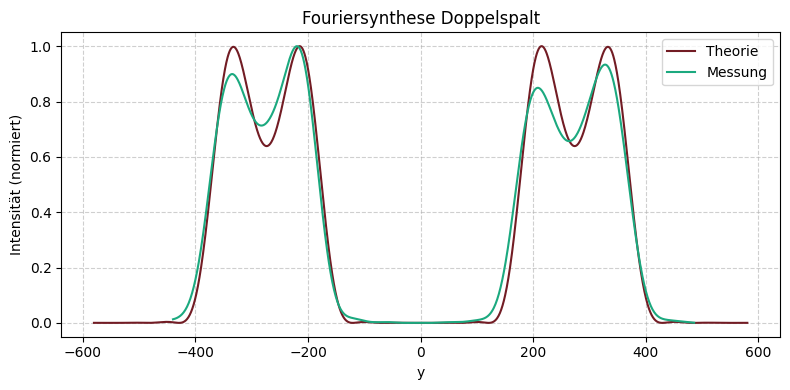

In [ ]:
aufgabe = '5b'
folder = "./A5/"
safe_folder = "../img/plots/"

# --------------------------------------
#   Anpassen der Messwerte
# --------------------------------------

# Auf Nullhöhe setzen
int_dop_2_null = int_dop_2 - min(int_dop_2)

x_exp = pix_pos_dop_2 - np.mean(pix_pos_dop_2)
I_exp = int_dop_2_null / np.max(int_dop_2_null)

# --------------------------------------
#  Plotting
# --------------------------------------
# Paraeter 
g = abst_b_val/px_breit
d = breit_b_val/px_breit
n = 2

y_th, I_th = synthese_doppelspalt(g, d, n)

# FWHM
fwhm_exp = fwhm(x_exp, I_exp)
fwhm_th = fwhm(y_th, I_th)
scale = fwhm_exp / fwhm_th

y_th_scaled = y_th * scale

plt.figure(figsize=(8,4))

plt.plot(
    y_th_scaled,
    I_th,
    color=weinrot, 
    label="Theorie"
    )

plt.plot(
    x_exp+23, 
    I_exp, 
    label="Messung",
    color=hellgruen
    )
plt.title("Fouriersynthese Doppelspalt")
plt.xlabel("y")
plt.ylabel("Intensität (normiert)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(f'{safe_folder}Doppelspalt_2Ordnung_{aufgabe}.pdf', dpi=300)
plt.show()

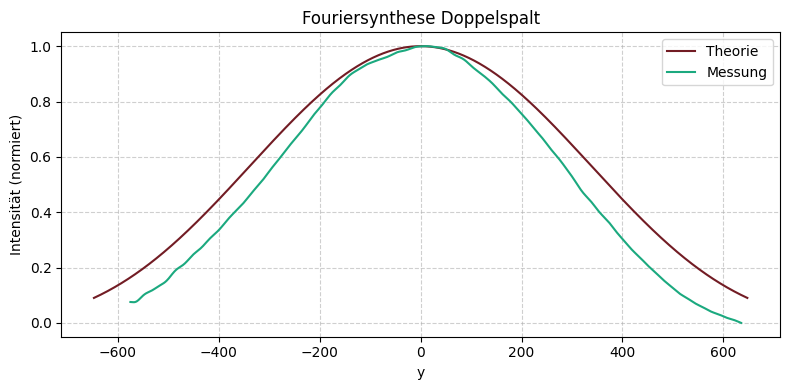

In [ ]:
# --------------------------------------
#  Manuelles anpassen von n
# --------------------------------------
# Paraeter 
g = abst_b_val/px_breit
d = breit_b_val/px_breit
n = 0.23 # Herauszufinden

y_th, I_th = synthese_doppelspalt(g, d, n)

# FWHM
fwhm_exp = fwhm(x_exp, I_exp)
fwhm_th = fwhm(y_th, I_th)
scale = fwhm_exp / fwhm_th

y_th_scaled = y_th * scale

# Auf Nullhöhe setzen
int_dop_0_null = int_dop_0 - min(int_dop_0)

x_exp = pix_pos_dop_0 - np.mean(pix_pos_dop_0)
I_exp = int_dop_0_null / np.max(int_dop_0_null)

plt.figure(figsize=(8,4))

plt.plot(
    y_th_scaled,
    I_th,
    color=weinrot, 
    label="Theorie"
    )

plt.plot(
    x_exp+30, 
    I_exp, 
    label="Messung",
    color=hellgruen
    )
plt.title("Fouriersynthese Doppelspalt")
plt.xlabel("y")
plt.ylabel("Intensität (normiert)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(f'{safe_folder}Doppelspalt_2Ordnung_{aufgabe}.pdf', dpi=300)
plt.show()

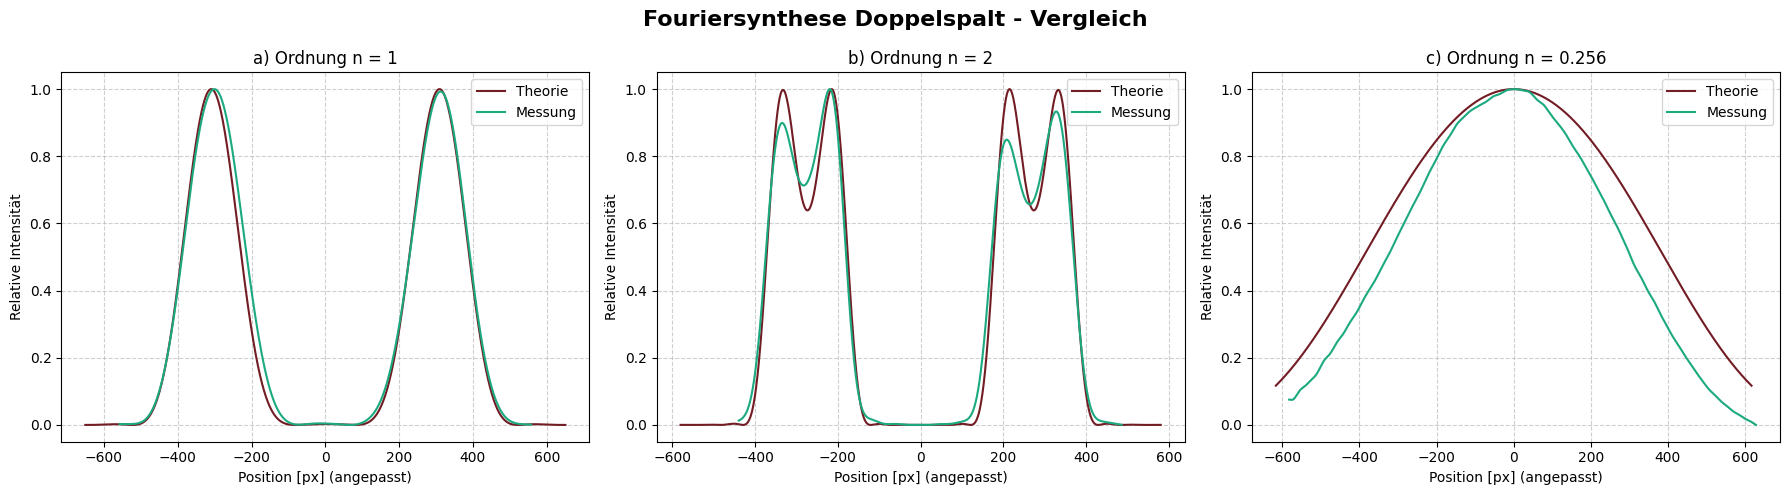

In [ ]:
g = abst_b_val / px_breit
d = breit_b_val / px_breit

def prepare_data(int_dop, pix_pos):
    I = int_dop - np.min(int_dop)
    I = I / np.max(I)
    x = pix_pos - np.mean(pix_pos)
    return x, I



x0, I0 = prepare_data(int_dop_0, pix_pos_dop_0)
x1, I1 = prepare_data(int_dop_1, pix_pos_dop_1)
x2, I2 = prepare_data(int_dop_2, pix_pos_dop_2)


# Theorie 1. Ordnun
n1 = 1
y1, I_th1 = synthese_doppelspalt(g, d, n1)
scale1 = fwhm(x1, I1) / fwhm(y1, I_th1)
y1 = y1 * scale1

# Theorie 2. Ordnung
n2 = 2
y2, I_th2 = synthese_doppelspalt(g, d, n2)
scale2 = fwhm(x2, I2) / fwhm(y2, I_th2)
y2 = y2 * scale2

# Theorie manuell (bestes n)
n3 = 0.256
y3, I_th3 = synthese_doppelspalt(g, d, n3)
scale3 = fwhm(x1, I1) / fwhm(y3, I_th3)
y3 = y3 * scale3


# Plot 1x3
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

axes[0].plot(y1, I_th1, color=weinrot, label="Theorie")
axes[0].plot(x1, I1, color=hellgruen, label="Messung")
axes[0].set_title("a) Ordnung n = 1")
axes[0].grid(True, which="both", linestyle="--", alpha=0.6)
axes[0].legend()
axes[0].set_xlabel('Position [px] (angepasst)')
axes[0].set_ylabel('Relative Intensität')



axes[1].plot(y2, I_th2, color=weinrot, label="Theorie")
axes[1].plot(x2+23, I2, color=hellgruen, label="Messung")
axes[1].set_title("b) Ordnung n = 2")
axes[1].grid(True, which="both", linestyle="--", alpha=0.6)
axes[1].legend()
axes[1].set_xlabel('Position [px] (angepasst)')
axes[1].set_ylabel('Relative Intensität')

axes[2].plot(y3, I_th3, color=weinrot, label="Theorie")
axes[2].plot(x0+23, I0, color=hellgruen, label="Messung")
axes[2].set_title(f"c) Ordnung n = {n3}")
axes[2].grid(True, which="both", linestyle="--", alpha=0.6)
axes[2].legend()
axes[2].set_xlabel('Position [px] (angepasst)')
axes[2].set_ylabel('Relative Intensität')

plt.suptitle("Fouriersynthese Doppelspalt - Vergleich", fontsize=16, weight='bold')
plt.savefig(f'{safe_folder}Kombiniert{aufgabe}.pdf', dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
def error(n, x_exp, I_exp, g, d):

    y_th, I_th = synthese_doppelspalt(g, d, n[0])

    # Theorie auf Mess-x interpolieren
    f = interp1d(y_th, I_th, kind='linear', bounds_error=False, fill_value=0)
    I_th_interp = f(x_exp)

    # Fehler (Least Squares)
    return np.sum((I_exp - I_th_interp)**2)

In [ ]:
aufgabe = '5c'
folder = "./A5/"
safe_folder = "../img/plots/"

# --
# Herausfinden der Kritischen Punktes
# --------------------------------------

# Auf Nullhöhe setzen
int_dop_0_null = int_dop_0 - min(int_dop_0)

x_exp = pix_pos_dop_0 - np.mean(pix_pos_dop_0)
I_exp = int_dop_0_null / np.max(int_dop_0_null)

# Fitten
n0 = [0.22]  # Startwert

res = minimize(
    error,
    n0,
    args=(x_exp, I_exp, g, d),
    method="Nelder-Mead"
)

n_fit = res.x[0]
print("Gefitteter Wert für n:", n_fit)


Gefitteter Wert für n: 0.3031015625000001


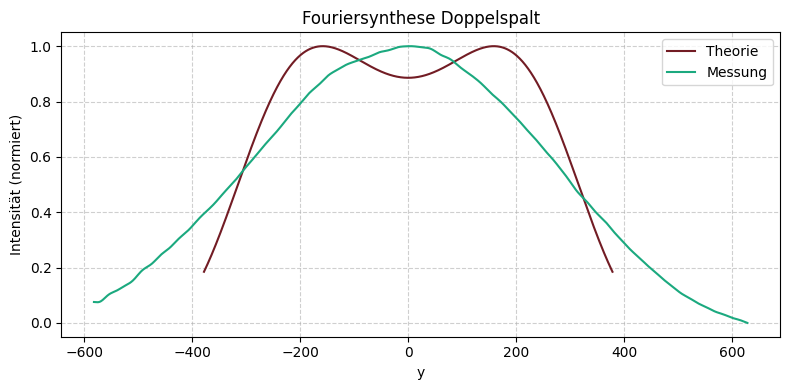

In [ ]:
# --------------------------------------
#  Plotting
# --------------------------------------
# Paraeter 
g = abst_b_val/px_breit
d = breit_b_val/px_breit
n = n_fit # Herauszufinden

y_th, I_th = synthese_doppelspalt(g, d, n)

# FWHM
fwhm_exp = fwhm(x_exp, I_exp)
fwhm_th = fwhm(y_th, I_th)
scale = fwhm_exp / fwhm_th

y_th_scaled = y_th * scale

plt.figure(figsize=(8,4))

plt.plot(
    y_th_scaled,
    I_th,
    color=weinrot, 
    label="Theorie"
    )

plt.plot(
    x_exp+23, 
    I_exp, 
    label="Messung",
    color=hellgruen
    )
plt.title("Fouriersynthese Doppelspalt")
plt.xlabel("y")
plt.ylabel("Intensität (normiert)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(f'{safe_folder}Doppelspalt_2Ordnung_{aufgabe}.pdf', dpi=300)
plt.show()

In [ ]:
def model(x, n, x0, A, B, g, d):
    
    # Theorie berechnen
    y_th, I_th = synthese_doppelspalt(g, d, n)
    
    # Interpolation auf Mess-x
    f = interp1d(y_th, I_th,
                 kind='linear',
                 bounds_error=False,
                 fill_value=0)
    
    I = f(x - x0)
    
    # Skalierung + Offset
    return A * I + B

def fit_wrapper(x, n, x0, A, B):
    return model(x, n, x0, A, B, g, d)

In [ ]:
# # Messdaten vorbereiten
# x_exp = pix_pos_dop_0 - np.mean(pix_pos_dop_0)
# I_exp = int_dop_0 - np.min(int_dop_0)

# # Normierung (optional, aber stabiler für Fit)
# I_exp = I_exp / np.max(I_exp)

# # Startwerte (wichtig für Stabilität!)
# p0 = [
#     0.25,  # n (Mitte des erlaubten Bereichs!)
#     0.0,   # x0
#     1.0,   # A
#     0.0    # B
# ]

# assert 0.2 <= p0[0] <= 0.3

# popt, pcov = curve_fit(
#     fit_wrapper,
#     x_exp,
#     I_exp,
#     p0=p0,
#     bounds=(
#         [0.2, -np.inf, -np.inf, -np.inf],   # untere Grenzen
#         [0.3,  np.inf,  np.inf,  np.inf]    # obere Grenzen
#     ),
#     maxfev=20000
# )

# n_fit, x0_fit, A_fit, B_fit = popt

# print("n =", n_fit)
# print("x0 =", x0_fit)
# print("A =", A_fit)
# print("B =", B_fit)

In [ ]:
# I_fit = fit_wrapper(x_exp, *popt)

# plt.figure(figsize=(8,4))

# plt.plot(x_exp, I_exp, label="Messung", color="green")
# plt.plot(x_exp, I_fit, label=f"Fit (n={n_fit:.3f})", color="red")

# plt.title("Sauberer Fit der Fouriersynthese")
# plt.xlabel("x (zentriert)")
# plt.ylabel("Intensität (normiert)")
# plt.grid(True, which="both", linestyle="--", alpha=0.6)
# plt.legend()

# plt.tight_layout()
# plt.show()

## Grenzfrequenzen

In [ ]:
# --------------------------------------
#  Bestimmung der theoretischen Grenzfrequenz für n = 1
# --------------------------------------

k_max_theo_1 = 2 * np.pi / spaltbreit_einzel / 1000

print(k_max_theo_1)

17.06439289905858


In [ ]:
# --------------------------------------
#  Bestimmung der experimentellen Grenzfrequenz für n = 1
# --------------------------------------

k = 2*np.pi/lam

k_max_exp_1 = 2*np.pi/(lam * f_l1 ) * 0.5 * breit_anaSpalt_1 / 1000
err_k_max_exp_1 = k * err_anaSpalt /f_l1 / 1000 

print(f'Experimentelle Grenzfrequenz: {k_max_exp_1:.0f} \\pm {err_k_max_exp_1:.1g}')

abw_1 = sigma_abweichung(k_max_theo_1, k_max_exp_1, err_k_max_exp_1)

print(f'Std.Abw.: {abw_1:.2f}')

Experimentelle Grenzfrequenz: 126 \pm 7
Std.Abw.: 14.79


In [ ]:
# --------------------------------------
#  Bestimmung der theoretischen Grenzfrequenz für n = 0.256
# --------------------------------------
# Einheiten werden in Meter umgerechnet
k_max_theo_0 = 2 *np.pi / spaltbreit_einzel * 0.256  / 1000
err_k_max_theo_0 = np.sqrt((2* np.pi * err_anaSpalt * 0.256)**2 + 0.008**2)

print(f'theoretische Grenzfrequenz: {k_max_theo_0:.3f} \\pm {err_k_max_theo_0:.1g}')


theoretische Grenzfrequenz: 4.368 \pm 0.008


In [ ]:
# --------------------------------------
#  Bestimmung der theoretischen Grenzfrequenz für n = 0.256
# --------------------------------------
# Einheiten werden in Meter umgerechnet
k = 2*np.pi/lam

k_max_exp_0 = k * 0.5 * breit_anaSpalt_0 /f_l1  / 1000
err_k_max_exp_0 = np.sqrt((k * 0.5 * err_anaSpalt /f_l1)**2)/ 1000

print(err_k_max_exp_0)

print(f'Experimentelle Grenzfrequenz: {k_max_exp_0:.0f} \\pm {err_k_max_exp_0:.1g}')

abw_0 = sigma_abweichung(k_max_exp_0, k_max_theo_0, err_k_max_exp_0, err_k_max_theo_0)

print(f'Std.Abw.: {abw_0:.2f}')

3.6907808430331217
Experimentelle Grenzfrequenz: 42 \pm 4
Std.Abw.: 10.22
